# Investigating the tradeoff between adversarial robustness and confidence calibration in ResNet models

In [ ]:
# Imports 
import numpy as np
import os
import sys
import torch
import torchvision
from torchvision import models
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

from models import get_resnet18
from train import train_one_epoch, evaluate
from calibration import (collect_predictions, compute_ece, reliability_diagram,
                          TemperatureScaler, collect_adversarial_predictions)
from attacks import adversarial_train_one_epoch, evaluate_clean_and_pgd
from data import CIFAR10_STATS, CIFAR100_STATS, IndexedDataset, get_cifar_loaders

# torch.backends.cudnndeterministic set to True for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [ ]:
# Pre-computed CIFAR normalisation stats (mean, std per channel)
# Using these directly spares time, as a loop does not have to be constructed to go over the whole dataset and aggregate values
print("CIFAR-10  stats:", CIFAR10_STATS)
print("CIFAR-100 stats:", CIFAR100_STATS)

CIFAR-10  stats: ((0.4914, 0.4822, 0.4465), (0.247, 0.2435, 0.2616))
CIFAR-100 stats: ((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))


In [ ]:
# get_cifar_loaders is imported from data.py
# 50000/ 5000 / 10000 split
# Return: train_subset, val_dataset, test_dataset, train_dl, val_dl, test_dl, classes, stats, num_classes
help(get_cifar_loaders)

Help on function get_cifar_loaders in module data:

get_cifar_loaders(dataset_name='cifar100', batch_size=128, val_fraction=0.1, seed=42)



In [ ]:
# Output directory helper (different runs, different folders, it helps future work for statistical validation, which requires more runs)
def make_output_dirs(dataset_name):

    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    
    base_dir = os.path.join("outputs", dataset_name.lower(), timestamp)

    model_dir = os.path.join(base_dir, "models")
    csv_dir = os.path.join(base_dir, "csv")
    plot_dir = os.path.join(base_dir, "plots")

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(csv_dir, exist_ok=True)
    os.makedirs(plot_dir, exist_ok=True)

    return timestamp, model_dir, csv_dir, plot_dir

In [ ]:
# Load train and test dataset
dataset_name = "cifar10"
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

(train_dataset, val_dataset, test_dataset,
 train_dl, val_dl, test_dl,
 classes, stats, num_classes) = get_cifar_loaders(dataset_name=dataset_name, batch_size=128)

timestamp, model_dir, csv_dir, plot_dir = make_output_dirs(dataset_name)

print(f"Train: {len(train_dataset):,}  |  Val: {len(val_dataset):,}  |  Test: {len(test_dataset):,}")
print(f"Num classes: {num_classes}")
print(f"Stats: {stats}")


c:\Users\leven\anaconda3\envs\thesis\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 45,000  |  Val: 5,000  |  Test: 10,000
Num classes: 10
Stats: ((0.4914, 0.4822, 0.4465), (0.247, 0.2435, 0.2616))


In [ ]:
# Inspect the dataset

for i in range(5):
    img, label = train_dataset[i]
    print(f"Index: {i}, Label: {label}, Shape: {img.shape}")

Index: 0, Label: 6, Shape: torch.Size([3, 32, 32])
Index: 1, Label: 2, Shape: torch.Size([3, 32, 32])
Index: 2, Label: 8, Shape: torch.Size([3, 32, 32])
Index: 3, Label: 6, Shape: torch.Size([3, 32, 32])
Index: 4, Label: 6, Shape: torch.Size([3, 32, 32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.5628136].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4814163..1.2890285].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5131699..2.0942786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9418434..1.7098198].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7830755..1.6463127].


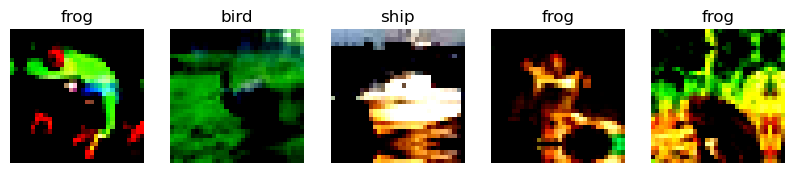

In [7]:
# Check preprocessed data with visualization


plt.figure(figsize=(10, 2))

for i in range(5):
    img, label = train_dataset[i]
    
    # convert tensor to image for imshow
    img = img.permute(1, 2, 0)  # (C,H,W) → (H,W,C)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.title(classes[label])
    plt.axis("off")

plt.show()

In [8]:
# Class names + examples:

print("Class names: ", classes)

horse_label = classes.index("horse")
print("Label for horses: ", horse_label)

horse_indices = [i for i, (_, label) in enumerate(train_dataset) if label == horse_label]

print("Number of horse pics: ", len(horse_indices))
print("First 10 horse indices: ", horse_indices[:10])

Class names:  ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Label for horses:  7
Number of horse pics:  4500
First 10 horse indices:  [15, 16, 24, 42, 58, 59, 62, 64, 65, 78]


In [ ]:
# get_resnet18 is imported from models.py
# CIFAR-friendliness: 3x3 stem conv (stride 1), no maxpool, fc adapted to num_classes
# Usage: get_resnet18(num_classes=100)
help(get_resnet18)

Help on function get_resnet18 in module models:

get_resnet18(num_classes=100)



In [ ]:
# Evaluate and train_one_epoch are imported from train.py
# evaluate(model, dataloader, criterion, device), it gives (avg_loss, accuracy)
# train_one_epoch(model, dataloader, criterion, optimizer, device), it gives (avg_loss, accuracy)
print("Training utilities loaded from train.py")

Training utilities loaded from train.py


In [ ]:
# ERM Baseline training with cross-entropy only
# It serves as a baseline to compare to
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
model  = get_resnet18(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

epochs = 30

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model, train_dl, criterion, optimizer, device)
    v_loss, v_acc = evaluate(model, val_dl, criterion, device)

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)

    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {t_loss:.4f}, Train Acc: {t_acc:.4f} | "
        f"Val Loss: {v_loss:.4f}, Val Acc: {v_acc:.4f}"
    )


Epoch [1/30] | Train Loss: 1.3476, Train Acc: 0.5094 | Val Loss: 1.1277, Val Acc: 0.6010
Epoch [2/30] | Train Loss: 0.9178, Train Acc: 0.6733 | Val Loss: 1.1054, Val Acc: 0.6338
Epoch [3/30] | Train Loss: 0.7385, Train Acc: 0.7404 | Val Loss: 0.8836, Val Acc: 0.7050
Epoch [4/30] | Train Loss: 0.6314, Train Acc: 0.7809 | Val Loss: 0.6480, Val Acc: 0.7776
Epoch [5/30] | Train Loss: 0.5586, Train Acc: 0.8064 | Val Loss: 0.6299, Val Acc: 0.7848
Epoch [6/30] | Train Loss: 0.5016, Train Acc: 0.8268 | Val Loss: 0.6366, Val Acc: 0.7970
Epoch [7/30] | Train Loss: 0.4597, Train Acc: 0.8408 | Val Loss: 0.6386, Val Acc: 0.7846
Epoch [8/30] | Train Loss: 0.4192, Train Acc: 0.8562 | Val Loss: 0.5269, Val Acc: 0.8202
Epoch [9/30] | Train Loss: 0.3899, Train Acc: 0.8664 | Val Loss: 0.4764, Val Acc: 0.8344
Epoch [10/30] | Train Loss: 0.3590, Train Acc: 0.8763 | Val Loss: 0.5645, Val Acc: 0.8094
Epoch [11/30] | Train Loss: 0.3273, Train Acc: 0.8888 | Val Loss: 0.4041, Val Acc: 0.8600
Epoch [12/30] | Tra

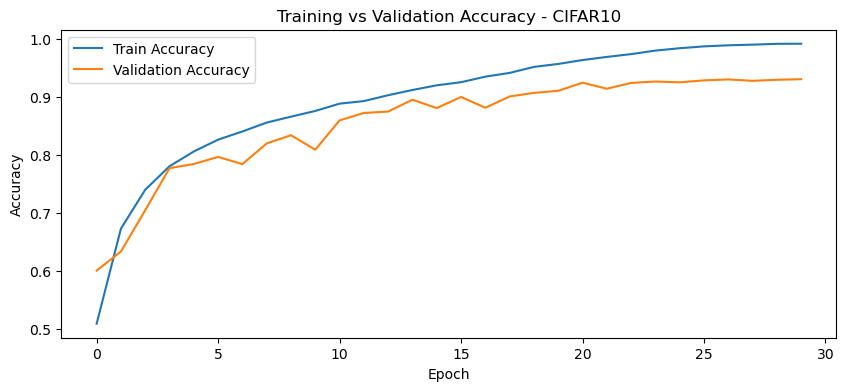

Accuracy plot saved to: outputs\cifar10\2026-05-03_12-25-01\plots\cifar10_accuracy.png


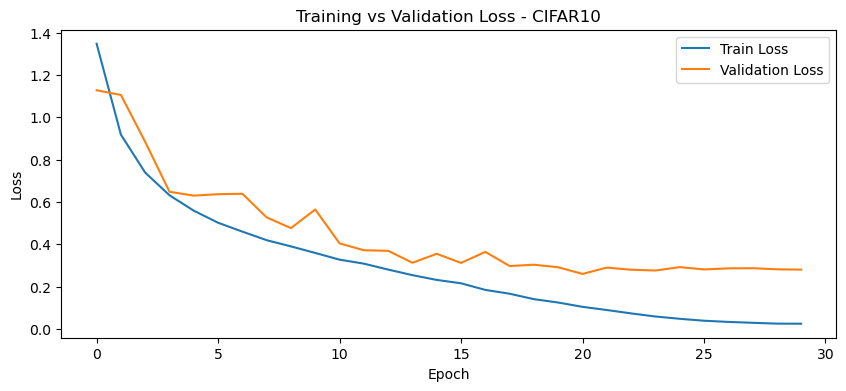

Loss plot saved to: outputs\cifar10\2026-05-03_12-25-01\plots\cifar10_loss.png


In [12]:
# Plotting progress

plt.figure(figsize=(10, 4))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title(f"Training vs Validation Accuracy - {dataset_name.upper()}")

acc_plot_path = os.path.join(plot_dir, f"{dataset_name}_accuracy.png")
plt.savefig(acc_plot_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Accuracy plot saved to: {acc_plot_path}")

plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title(f"Training vs Validation Loss - {dataset_name.upper()}")

loss_plot_path = os.path.join(plot_dir, f"{dataset_name}_loss.png")
plt.savefig(loss_plot_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Loss plot saved to: {loss_plot_path}")

In [ ]:
def denormalize(images, stats):
    """Reverse per-channel normalisation for display purposes"""
    means = torch.tensor(stats[0]).view(1, 3, 1, 1).to(images.device)
    stds = torch.tensor(stats[1]).view(1, 3, 1, 1).to(images.device)
    return images * stds + means

In [ ]:
@torch.no_grad()
def get_test_predictions_with_confidence(model, dataloader, class_names):
    """Collect per-sample predictions, confidences, and labels on the test set"""
    model.eval()
    all_results = []

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, dim=1)

        for i in range(images.size(0)):
            all_results.append({
                "true_label_idx": labels[i].item(),
                "true_label":     class_names[labels[i].item()],
                "pred_label_idx": preds[i].item(),
                "pred_label":     class_names[preds[i].item()],
                "confidence":     confs[i].item(),
                "correct":        preds[i].item() == labels[i].item(),
            })

    return all_results

test_results = get_test_predictions_with_confidence(model, test_dl, classes)
print("Number of test results:", len(test_results))
print(test_results[:3])

Number of test results: 10000
[{'true_label_idx': 3, 'true_label': 'cat', 'pred_label_idx': 3, 'pred_label': 'cat', 'confidence': 0.9999995231628418, 'correct': True}, {'true_label_idx': 8, 'true_label': 'ship', 'pred_label_idx': 8, 'pred_label': 'ship', 'confidence': 1.0, 'correct': True}, {'true_label_idx': 8, 'true_label': 'ship', 'pred_label_idx': 8, 'pred_label': 'ship', 'confidence': 0.9999310970306396, 'correct': True}]


In [15]:
def get_prediction_stats(test_results, class_names, correct=True):
    """
    Returns:
        counts_per_class: list of counts for each predicted class
        avg_conf_per_class: list of average confidence for each predicted class
    """
    num_classes = len(class_names)

    counts = [0] * num_classes
    conf_sums = [0.0] * num_classes

    for result in test_results:
        if result["correct"] == correct:
            pred_idx = result["pred_label_idx"]
            counts[pred_idx] += 1
            conf_sums[pred_idx] += result["confidence"]

    avg_conf = []
    for i in range(num_classes):
        if counts[i] > 0:
            avg_conf.append(conf_sums[i] / counts[i])
        else:
            avg_conf.append(0.0)

    return counts, avg_conf

In [ ]:
def plot_prediction_distribution(test_results, class_names, correct=True, figsize=(14, 6)):
    "Plots the prediction distribution"
    counts, avg_conf = get_prediction_stats(test_results, class_names, correct=correct)

    x = np.arange(len(class_names))
    title_type = "Correct" if correct else "Incorrect"

    fig, ax1 = plt.subplots(figsize=figsize)

    # Bar plot for counts
    ax1.bar(x, counts, alpha=0.7)
    ax1.set_xlabel("Predicted Class")
    ax1.set_ylabel("Number of Predictions")
    ax1.set_title(f"{title_type} Predictions per Class + Average Confidence")
    ax1.set_xticks(x)
    ax1.set_xticklabels(class_names, rotation=45, ha="right")

    # Second axis for average confidence
    ax2 = ax1.twinx()
    ax2.plot(x, avg_conf, marker='o')
    ax2.set_ylabel("Average Confidence")
    ax2.set_ylim(0, 1)
    
    plt.tight_layout()
    if correct == True:
        correctness_true_plot_path = os.path.join(plot_dir, f"{dataset_name}_correctness_predictions_true.png")
        plt.savefig(correctness_true_plot_path, bbox_inches="tight", dpi=300)
    else:
        correctness_false_plot_path = os.path.join(plot_dir, f"{dataset_name}_correctness_predictions_false.png")
        plt.savefig(correctness_false_plot_path, bbox_inches="tight", dpi=300)
        
    
    plt.show()

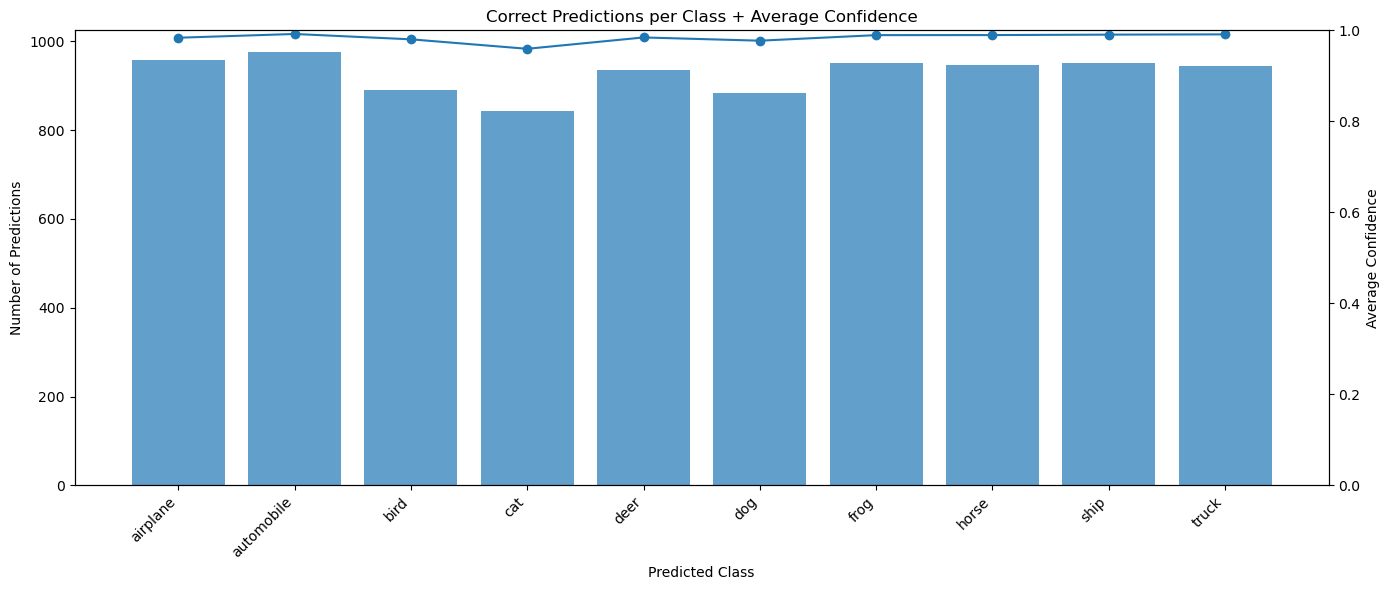

In [ ]:
# Correctly classified image counts
plot_prediction_distribution(test_results, classes, correct=True)

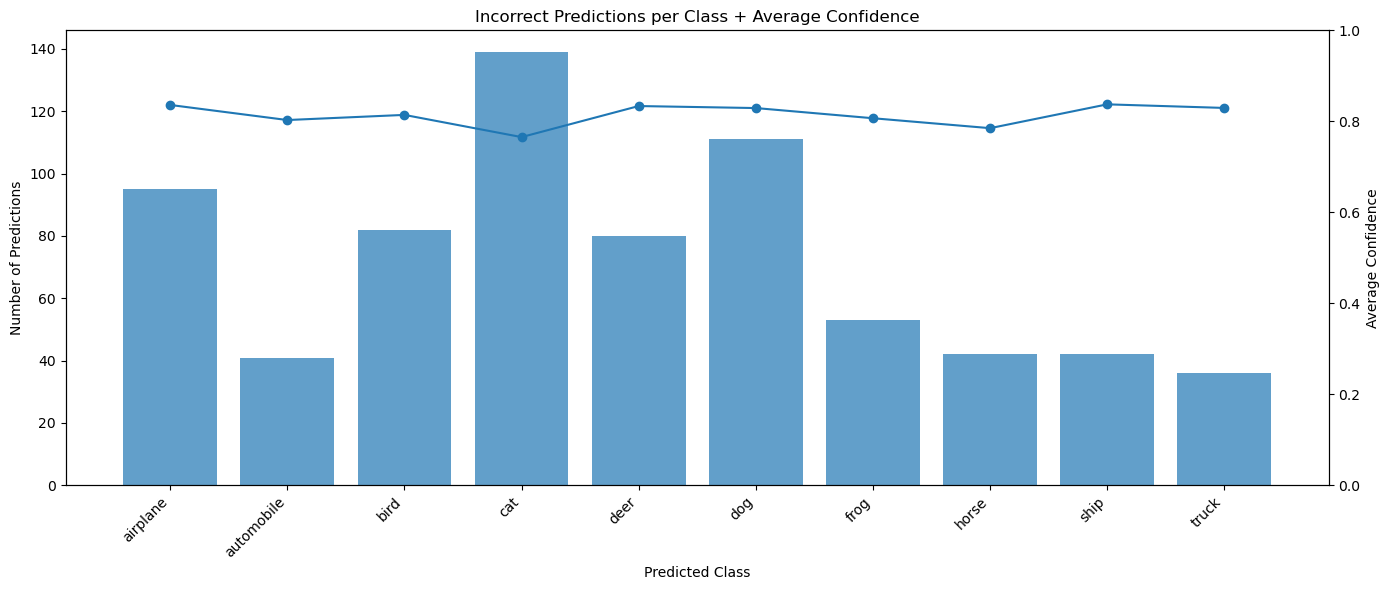

In [ ]:
# Incorrectly classified image counts
plot_prediction_distribution(test_results, classes, correct=False)

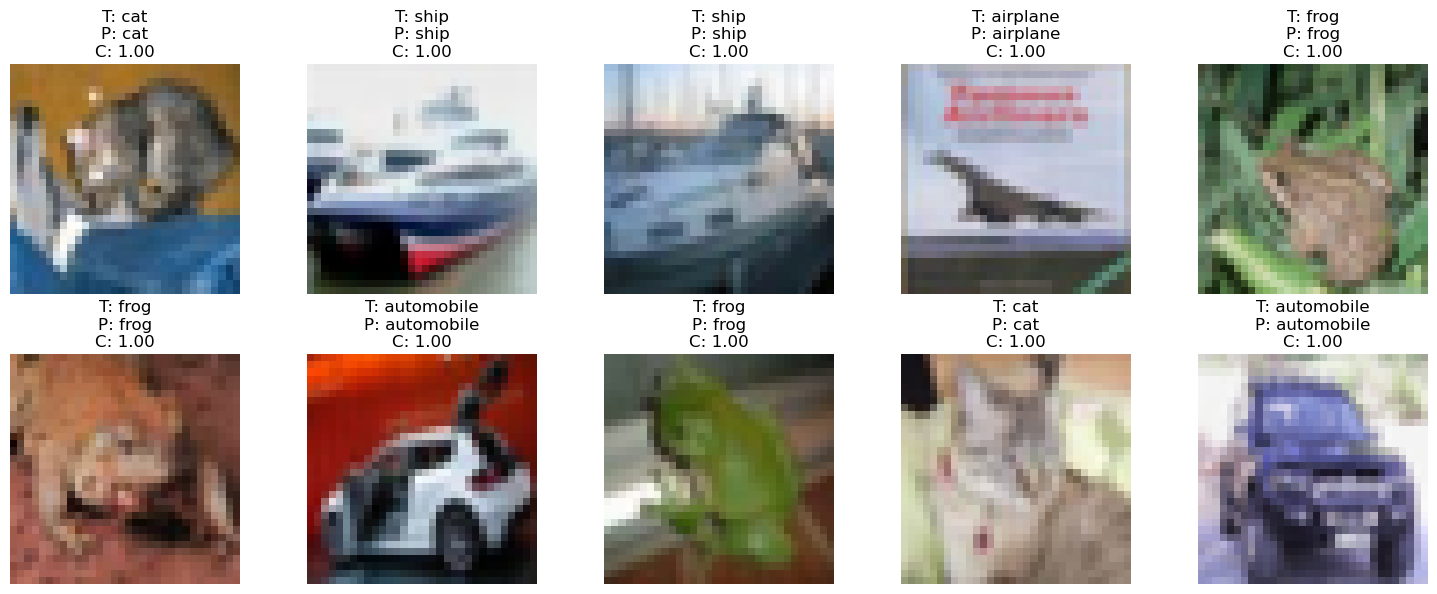

In [ ]:

def show_test_predictions(model, dataset, class_names, num_images=10):
    "Show test images with prediction and confidence"
    model.eval()

    plt.figure(figsize=(15, 6))

    for i in range(num_images):
        image, label = dataset[i]

        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1)
            conf, pred = torch.max(probs, dim=1)

        # unnormalize for display
        img_show = image.unsqueeze(0).to(device)
        img_show = denormalize(img_show, stats).squeeze(0).cpu()
        img_show = img_show.permute(1, 2, 0).clamp(0, 1)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img_show)
        plt.title(
            f"T: {class_names[label]}\n"
            f"P: {class_names[pred.item()]}\n"
            f"C: {conf.item():.2f}"
        )
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_test_predictions(model, test_dataset, classes, num_images=10)

In [ ]:
# Save results to csv
df_results = pd.DataFrame(test_results)

csv_path = os.path.join(csv_dir, f"{dataset_name}_test_predictions_with_confidence.csv")
df_results.to_csv(csv_path, index=False)

print(f"CSV saved to: {csv_path}")

CSV saved to: outputs\cifar10\2026-05-03_12-25-01\csv\cifar10_test_predictions_with_confidence.csv


In [21]:
# Save model
model_path = os.path.join(model_dir, f"resnet18_{dataset_name}.pth")
torch.save(model.state_dict(), model_path)
print(f"Model saved to: {model_path}")

Model saved to: outputs\cifar10\2026-05-03_12-25-01\models\resnet18_cifar10.pth


## Calibration Evaluation — ECE & Reliability Diagram

**Expected Calibration Error (ECE)** measures the average gap between a model's predicted confidence and its actual accuracy, bucketed across confidence intervals. A perfectly calibrated model has ECE = 0. The reliability diagram shows this visually, as bars above the diagonal mean overconfidence, bars below mean underconfidence.

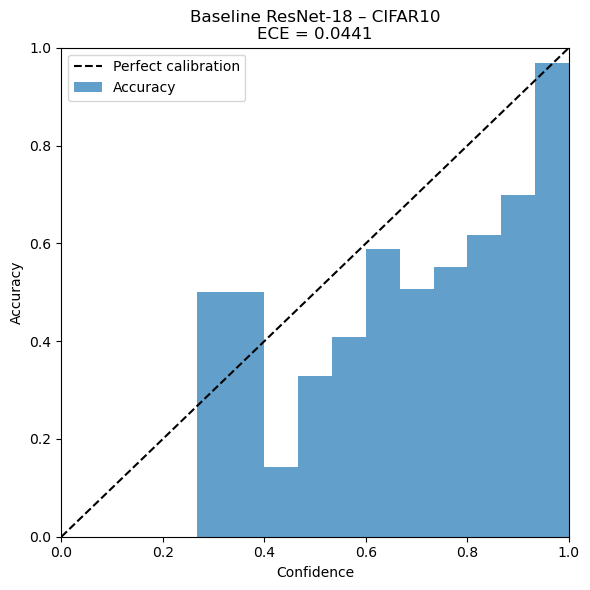

ECE (baseline): 0.0441


In [22]:
# Collect max-confidence predictions on the test set
confs, preds, labels_np = collect_predictions(model, test_dl, device)

ece = reliability_diagram(
    confs, preds, labels_np,
    title=f"Baseline ResNet-18 – {dataset_name.upper()}",
    save_path=os.path.join(plot_dir, f"{dataset_name}_reliability_baseline.png"),
)
print(f"ECE (baseline): {ece:.4f}")

## Temperature Scaling (Post-hoc Calibration)

Temperature scaling divides the model's logits by a single learned scalar T before the softmax. T > 1 makes the distribution softer (less overconfident). It is fit by minimising NLL on the held-out validation set and does not change accuracy at all.

Optimal temperature: 1.2028


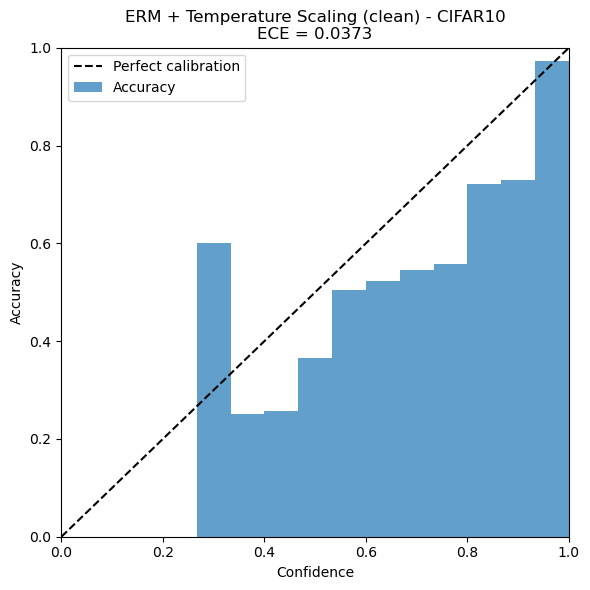

ECE before scaling : 0.0441
ECE after  scaling : 0.0373
Temperature T      : 1.2028


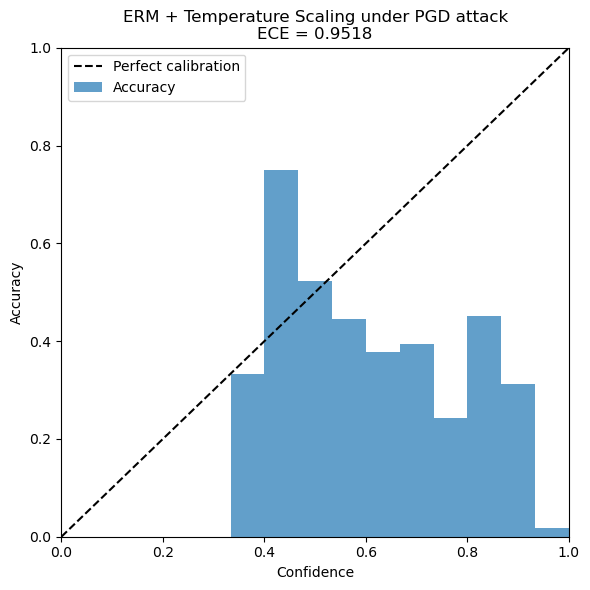

ECE adv (TS)       : 0.9518


In [ ]:
# Fit temperature T on the validation set (minimising NLL)
ts_model = TemperatureScaler(model).to(device)
ts_model.fit(val_dl, device)


# ECE on clean test set
ts_confs, ts_preds, ts_labels = collect_predictions(ts_model, test_dl, device)
ts_ece = reliability_diagram(
    ts_confs, ts_preds, ts_labels,
    title=f"ERM + Temperature Scaling (clean) - {dataset_name.upper()}",
    save_path=os.path.join(plot_dir, f"{dataset_name}_reliability_ts.png"),
)
print(f"ECE before scaling : {ece:.4f}")
print(f"ECE after  scaling : {ts_ece:.4f}")
print(f"Temperature T      : {ts_model.temperature.item():.4f}")

# ECE under PGD attack (key thesis metric)
adv_confs_ts, adv_preds_ts, _ = collect_adversarial_predictions(ts_model, test_dl, device)
adv_ece_ts = reliability_diagram(
    adv_confs_ts, adv_preds_ts, ts_labels,
    title="ERM + Temperature Scaling under PGD attack",
    save_path=os.path.join(plot_dir, f"{dataset_name}_reliability_ts_adv.png"),
)
print(f"ECE adv (TS)       : {adv_ece_ts:.4f}")


## PGD Adversarial Attack

Measure how robust the baseline model is against a 10-step PGD L∞ attack with ε = 8/255. The gap between clean accuracy and PGD accuracy quantifies vulnerability.

In [25]:
# Evaluate clean accuracy and PGD-10 robustness on the test set
clean_acc, pgd_acc = evaluate_clean_and_pgd(
    model, test_dl, device, eps=8/255, alpha=2/255, steps=10
)
print(f"Baseline model:")
print(f"  Clean accuracy : {clean_acc:.4f}")
print(f"  PGD-10 accuracy: {pgd_acc:.4f}")
print(f"  Robustness gap : {clean_acc - pgd_acc:.4f}")

Baseline model:
  Clean accuracy : 0.9279
  PGD-10 accuracy: 0.0381
  Robustness gap : 0.8898


## Adversarial Training (Madry PGD)

Retrain a fresh ResNet-18 using PGD-generated adversarial examples in the training loop (Madry et al., 2018). This trades some clean accuracy for robustness. Afterwards the thesis measures both robustness (PGD-10) and calibration (ECE) so we can compare all three axes, namely, clean accuracy, adversarial accuracy, and ECE.

c:\Users\leven\Downloads\Thesis\attacks.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler  = GradScaler(enabled=device.type == 'cuda')
c:\Users\leven\Downloads\Thesis\attacks.py:69: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=device.type == 'cuda'):


Epoch [1/30] | Train Loss: 1.6754, Train Acc: 0.3737 | Val Loss: 1.2546, Val Acc: 0.5552
Epoch [2/30] | Train Loss: 1.3807, Train Acc: 0.4878 | Val Loss: 1.0968, Val Acc: 0.6102
Epoch [3/30] | Train Loss: 1.2200, Train Acc: 0.5479 | Val Loss: 0.8945, Val Acc: 0.6930
Epoch [4/30] | Train Loss: 1.1173, Train Acc: 0.5895 | Val Loss: 0.8036, Val Acc: 0.7168
Epoch [5/30] | Train Loss: 1.0483, Train Acc: 0.6168 | Val Loss: 0.7263, Val Acc: 0.7522
Epoch [6/30] | Train Loss: 0.9823, Train Acc: 0.6393 | Val Loss: 0.6502, Val Acc: 0.7836
Epoch [7/30] | Train Loss: 0.9296, Train Acc: 0.6636 | Val Loss: 0.6500, Val Acc: 0.7786
Epoch [8/30] | Train Loss: 0.8823, Train Acc: 0.6771 | Val Loss: 0.5547, Val Acc: 0.8030
Epoch [9/30] | Train Loss: 0.8420, Train Acc: 0.6941 | Val Loss: 0.5482, Val Acc: 0.8046
Epoch [10/30] | Train Loss: 0.8055, Train Acc: 0.7060 | Val Loss: 0.5032, Val Acc: 0.8428
Epoch [11/30] | Train Loss: 0.7635, Train Acc: 0.7220 | Val Loss: 0.4798, Val Acc: 0.8384
Epoch [12/30] | Tra

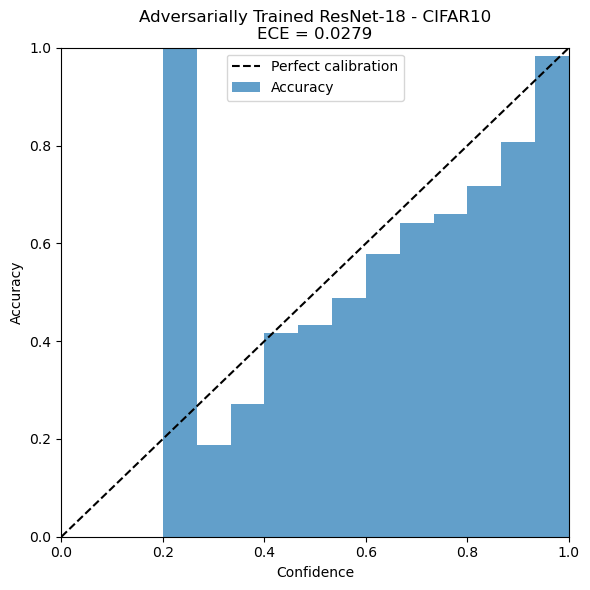

ECE (adv trained): 0.0279
Adversarial model saved to: outputs\cifar10\2026-05-03_12-25-01\models\resnet18_cifar10_adv.pth


In [ ]:
# Adversarial Training (Madry PGD)
torch.manual_seed(SEED)
adv_model     = get_resnet18(num_classes=num_classes).to(device)
adv_criterion = nn.CrossEntropyLoss()
adv_optimizer = torch.optim.Adam(adv_model.parameters(), lr=1e-3, weight_decay=1e-4)
adv_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(adv_optimizer, T_max=30)

adv_epochs  = 30
adv_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(adv_epochs):
    t_loss, t_acc = adversarial_train_one_epoch(
        adv_model, train_dl, adv_criterion, adv_optimizer, device,
        eps=8/255, alpha=2/255, steps=7
    )
    v_loss, v_acc = evaluate(adv_model, val_dl, adv_criterion, device)
    adv_scheduler.step()

    adv_history["train_loss"].append(t_loss)
    adv_history["train_acc"].append(t_acc)
    adv_history["val_loss"].append(v_loss)
    adv_history["val_acc"].append(v_acc)

    print(
        f"Epoch [{epoch+1}/{adv_epochs}] | "
        f"Train Loss: {t_loss:.4f}, Train Acc: {t_acc:.4f} | "
        f"Val Loss: {v_loss:.4f}, Val Acc: {v_acc:.4f}"
    )

adv_clean_acc, adv_pgd_acc = evaluate_clean_and_pgd(
    adv_model, test_dl, device, eps=8/255, alpha=2/255, steps=10
)
print(f"\nAdversarially trained model:")
print(f"  Clean accuracy : {adv_clean_acc:.4f}")
print(f"  PGD-10 accuracy: {adv_pgd_acc:.4f}")

adv_confs, adv_preds, adv_labels_np = collect_predictions(adv_model, test_dl, device)
adv_ece = reliability_diagram(
    adv_confs, adv_preds, adv_labels_np,
    title=f"Adversarially Trained ResNet-18 - {dataset_name.upper()}",
    save_path=os.path.join(plot_dir, f"{dataset_name}_reliability_adv.png"),
)
print(f"ECE (adv trained): {adv_ece:.4f}")

adv_model_path = os.path.join(model_dir, f"resnet18_{dataset_name}_adv.pth")
torch.save(adv_model.state_dict(), adv_model_path)
print(f"Adversarial model saved to: {adv_model_path}")


## Adversarial Calibration (ECE under attack)

The key thesis metric: how well calibrated is each model when the input is **adversarially perturbed**?
A model should output low confidence when it is wrong under attack. CCAT is specifically designed for this.

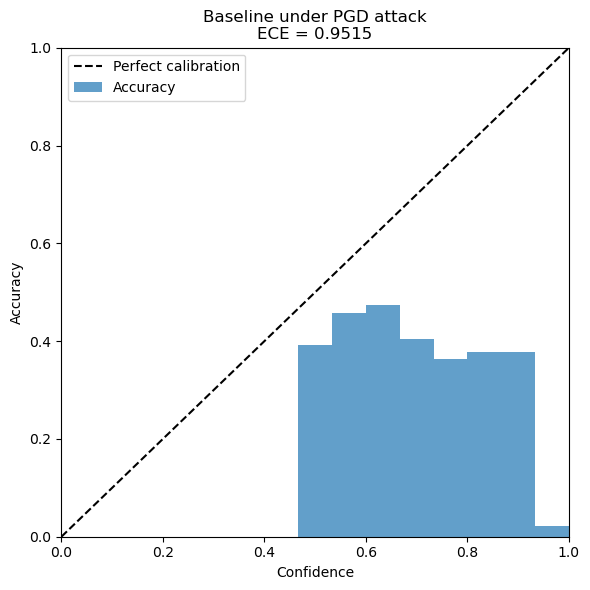

Baseline  ECE clean=0.0441  ECE adv=0.9515


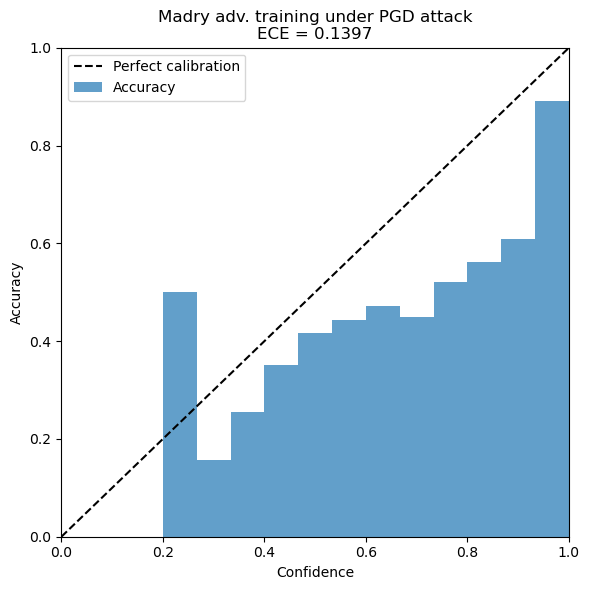

Madry     ECE clean=0.0279  ECE adv=0.1397


In [27]:
import importlib, calibration
importlib.reload(calibration)
from calibration import (collect_predictions, compute_ece, reliability_diagram,
                          TemperatureScaler, collect_adversarial_predictions)

# Baseline adversarial ECE
adv_confs_base, adv_preds_base, adv_labels_base = collect_adversarial_predictions(model, test_dl, device)
adv_ece_base = reliability_diagram(
    adv_confs_base, adv_preds_base, adv_labels_base,
    title='Baseline under PGD attack',
    save_path=os.path.join(plot_dir, f'{dataset_name}_reliability_base_adv.png'),
)
print(f'Baseline  ECE clean={ece:.4f}  ECE adv={adv_ece_base:.4f}')

# Madry adversarial ECE
adv_confs_madry, adv_preds_madry, adv_labels_madry = collect_adversarial_predictions(adv_model, test_dl, device)
adv_ece_madry = reliability_diagram(
    adv_confs_madry, adv_preds_madry, adv_labels_madry,
    title='Madry adv. training under PGD attack',
    save_path=os.path.join(plot_dir, f'{dataset_name}_reliability_madry_adv.png'),
)
print(f'Madry     ECE clean={adv_ece:.4f}  ECE adv={adv_ece_madry:.4f}')


## CRL — Contrastive Representation Learning

Integrate the CRL loss as a replacement for standard cross-entropy. CRL encourages representations of correctly classified samples to be clustered and misclassified samples to be pushed apart, which has been shown to improve calibration without sacrificing accuracy.

Epoch [1/30] Train 0.5094 | Val 0.6010
Epoch [2/30] Train 0.6648 | Val 0.6418
Epoch [3/30] Train 0.7285 | Val 0.7264
Epoch [4/30] Train 0.7660 | Val 0.7296
Epoch [5/30] Train 0.7927 | Val 0.8034
Epoch [6/30] Train 0.8150 | Val 0.8010
Epoch [7/30] Train 0.8261 | Val 0.8006
Epoch [8/30] Train 0.8411 | Val 0.8178
Epoch [9/30] Train 0.8493 | Val 0.8322
Epoch [10/30] Train 0.8608 | Val 0.8338
Epoch [11/30] Train 0.8717 | Val 0.8566
Epoch [12/30] Train 0.8796 | Val 0.8646
Epoch [13/30] Train 0.8884 | Val 0.8810
Epoch [14/30] Train 0.8968 | Val 0.8770
Epoch [15/30] Train 0.9038 | Val 0.8764
Epoch [16/30] Train 0.9107 | Val 0.8766
Epoch [17/30] Train 0.9207 | Val 0.8788
Epoch [18/30] Train 0.9234 | Val 0.8994
Epoch [19/30] Train 0.9330 | Val 0.9014
Epoch [20/30] Train 0.9395 | Val 0.9062
Epoch [21/30] Train 0.9478 | Val 0.9110
Epoch [22/30] Train 0.9506 | Val 0.9104
Epoch [23/30] Train 0.9564 | Val 0.9190
Epoch [24/30] Train 0.9628 | Val 0.9154
Epoch [25/30] Train 0.9694 | Val 0.9176
Epoch [26

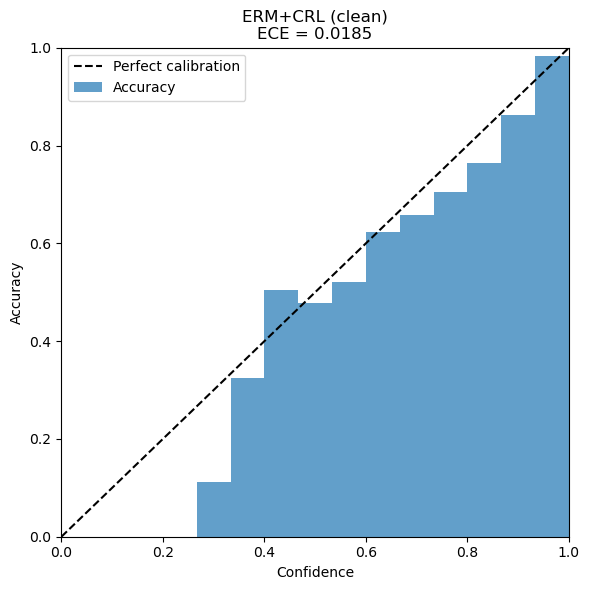

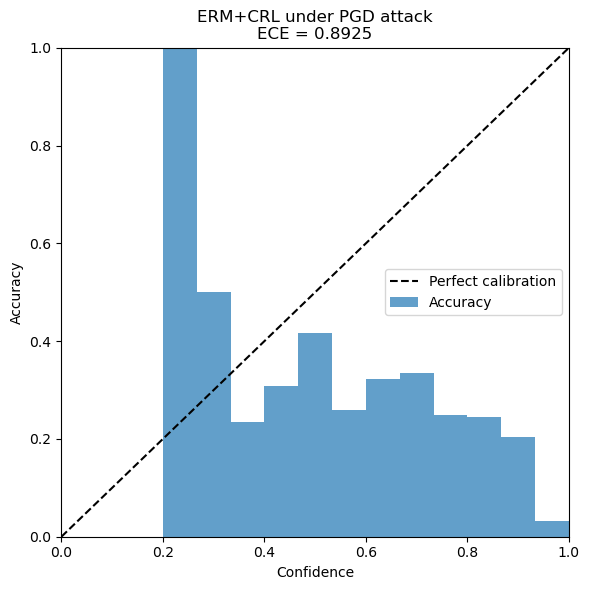

CRL  Clean=0.9229  PGD=0.0670  ECE clean=0.0185  ECE adv=0.8925


In [28]:
from data import IndexedDataset
import importlib, crl as crl_mod
importlib.reload(crl_mod)
from crl import History, crl_train_one_epoch

crl_train_dl = DataLoader(
    IndexedDataset(train_dataset),
    batch_size=128, shuffle=True, num_workers=0, pin_memory=True
)

torch.manual_seed(SEED)
crl_model     = get_resnet18(num_classes=num_classes).to(device)
crl_criterion = nn.CrossEntropyLoss()
crl_optimizer = torch.optim.Adam(crl_model.parameters(), lr=1e-3, weight_decay=1e-4)
crl_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(crl_optimizer, T_max=30)
crl_history   = History(n_data=len(train_dataset))

crl_epochs = 30
for epoch in range(crl_epochs):
    t_loss, t_acc = crl_train_one_epoch(
        crl_model, crl_train_dl, crl_criterion, crl_optimizer, crl_history, device,
        epoch=epoch, rank_target='softmax', rank_weight=1.0, num_classes=num_classes
    )
    v_loss, v_acc = evaluate(crl_model, val_dl, crl_criterion, device)
    crl_scheduler.step()
    print(f'Epoch [{epoch+1}/{crl_epochs}] Train {t_acc:.4f} | Val {v_acc:.4f}')

crl_clean_acc, crl_pgd_acc = evaluate_clean_and_pgd(crl_model, test_dl, device, eps=8/255, steps=10)
crl_confs, crl_preds, crl_labels_np = collect_predictions(crl_model, test_dl, device)
crl_ece = reliability_diagram(crl_confs, crl_preds, crl_labels_np,
    title='ERM+CRL (clean)',
    save_path=os.path.join(plot_dir, f'{dataset_name}_reliability_crl.png'))
adv_confs_crl, adv_preds_crl, _ = collect_adversarial_predictions(crl_model, test_dl, device)
adv_ece_crl = reliability_diagram(adv_confs_crl, adv_preds_crl, crl_labels_np,
    title='ERM+CRL under PGD attack',
    save_path=os.path.join(plot_dir, f'{dataset_name}_reliability_crl_adv.png'))
print(f'CRL  Clean={crl_clean_acc:.4f}  PGD={crl_pgd_acc:.4f}  ECE clean={crl_ece:.4f}  ECE adv={adv_ece_crl:.4f}')
torch.save(crl_model.state_dict(), os.path.join(model_dir, f'resnet18_{dataset_name}_crl.pth'))


c:\Users\leven\Downloads\Thesis\crl.py:128: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=device.type == 'cuda')
c:\Users\leven\Downloads\Thesis\crl.py:144: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=device.type == 'cuda'):


Epoch [1/30] Train 0.3646 | Val 0.5418
Epoch [2/30] Train 0.4795 | Val 0.6074
Epoch [3/30] Train 0.5378 | Val 0.6838
Epoch [4/30] Train 0.5754 | Val 0.7142
Epoch [5/30] Train 0.6051 | Val 0.7580
Epoch [6/30] Train 0.6249 | Val 0.7572
Epoch [7/30] Train 0.6489 | Val 0.7790
Epoch [8/30] Train 0.6637 | Val 0.7990
Epoch [9/30] Train 0.6802 | Val 0.8180
Epoch [10/30] Train 0.6927 | Val 0.8254
Epoch [11/30] Train 0.7087 | Val 0.8350
Epoch [12/30] Train 0.7193 | Val 0.8432
Epoch [13/30] Train 0.7313 | Val 0.8512
Epoch [14/30] Train 0.7419 | Val 0.8484
Epoch [15/30] Train 0.7546 | Val 0.8600
Epoch [16/30] Train 0.7665 | Val 0.8734
Epoch [17/30] Train 0.7771 | Val 0.8742
Epoch [18/30] Train 0.7908 | Val 0.8752
Epoch [19/30] Train 0.8024 | Val 0.8828
Epoch [20/30] Train 0.8142 | Val 0.8886
Epoch [21/30] Train 0.8282 | Val 0.8920
Epoch [22/30] Train 0.8386 | Val 0.8930
Epoch [23/30] Train 0.8516 | Val 0.8942
Epoch [24/30] Train 0.8604 | Val 0.8978
Epoch [25/30] Train 0.8695 | Val 0.8994
Epoch [26

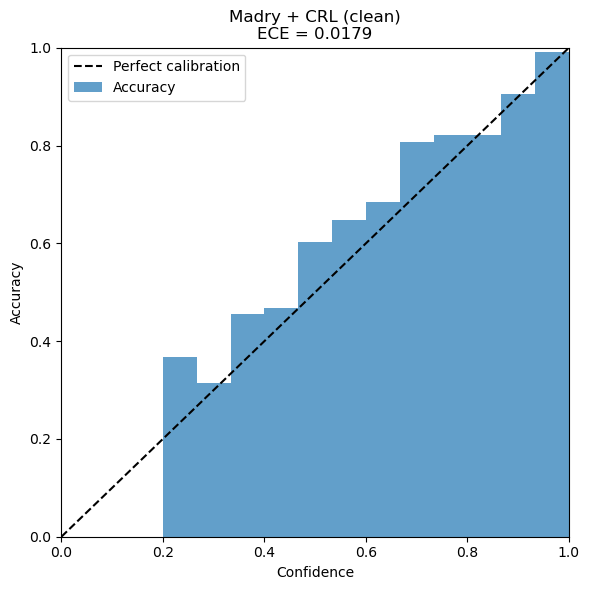

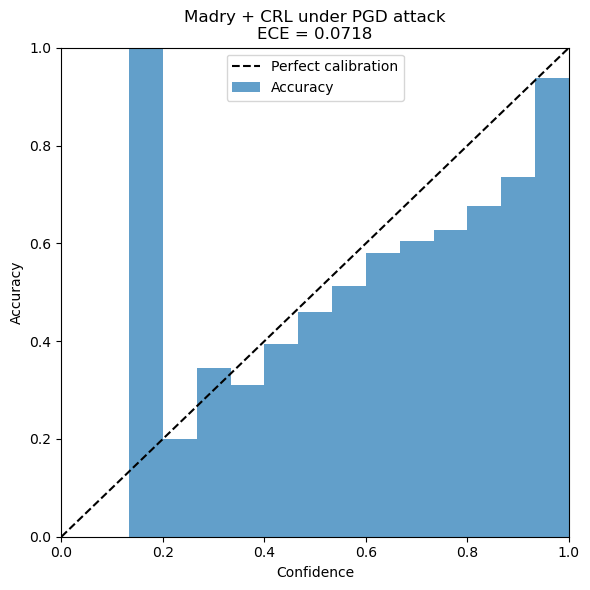

Madry+CRL  Clean=0.9059  PGD=0.7717  ECE clean=0.0179  ECE adv=0.0718


In [ ]:
# Train Madry + CRL, a new approach to the author's knowledge, not proposed by literature when the thesis was written
from data import IndexedDataset
import importlib, crl as crl_mod
importlib.reload(crl_mod)
from crl import History, madry_crl_train_one_epoch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


madry_crl_train_dl = DataLoader(
    IndexedDataset(train_dataset),
    batch_size=128, shuffle=True, num_workers=0, pin_memory=True
)

torch.manual_seed(SEED)
madry_crl_model     = get_resnet18(num_classes=num_classes).to(device)
madry_crl_criterion = nn.CrossEntropyLoss()
madry_crl_optimizer = torch.optim.Adam(madry_crl_model.parameters(), lr=1e-3, weight_decay=1e-4)
madry_crl_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(madry_crl_optimizer, T_max=30)
madry_crl_history   = History(n_data=len(train_dataset))

madry_crl_epochs = 30
for epoch in range(madry_crl_epochs):
    t_loss, t_acc = madry_crl_train_one_epoch(
        madry_crl_model, madry_crl_train_dl, madry_crl_criterion, madry_crl_optimizer,
        madry_crl_history, device,
        epoch=epoch, rank_target='softmax', rank_weight=1.0, num_classes=num_classes,
        eps=8/255, alpha=2/255, steps=7
    )
    v_loss, v_acc = evaluate(madry_crl_model, val_dl, madry_crl_criterion, device)
    madry_crl_scheduler.step()
    print(f'Epoch [{epoch+1}/{madry_crl_epochs}] Train {t_acc:.4f} | Val {v_acc:.4f}')

madry_crl_clean_acc, madry_crl_pgd_acc = evaluate_clean_and_pgd(
    madry_crl_model, test_dl, device, eps=8/255, steps=10)
madry_crl_confs, madry_crl_preds, madry_crl_labels_np = collect_predictions(
    madry_crl_model, test_dl, device)
madry_crl_ece = reliability_diagram(
    madry_crl_confs, madry_crl_preds, madry_crl_labels_np,
    title='Madry + CRL (clean)',
    save_path=os.path.join(plot_dir, f'{dataset_name}_reliability_madry_crl.png'))
adv_confs_madry_crl, adv_preds_madry_crl, _ = collect_adversarial_predictions(
    madry_crl_model, test_dl, device)
adv_ece_madry_crl = reliability_diagram(
    adv_confs_madry_crl, adv_preds_madry_crl, madry_crl_labels_np,
    title='Madry + CRL under PGD attack',
    save_path=os.path.join(plot_dir, f'{dataset_name}_reliability_madry_crl_adv.png'))
print(f'Madry+CRL  Clean={madry_crl_clean_acc:.4f}  PGD={madry_crl_pgd_acc:.4f}  ECE clean={madry_crl_ece:.4f}  ECE adv={adv_ece_madry_crl:.4f}')
torch.save(madry_crl_model.state_dict(), os.path.join(model_dir, f'resnet18_{dataset_name}_madry_crl.pth'))


## CCAT — Confidence-Calibrated Adversarial Training

CCAT (Stutz et al., 2020) extends adversarial training so that adversarial examples receive uniformly distributed (low-confidence) predictions rather than incorrect high-confidence ones. This directly targets the calibration-robustness tradeoff and is the most complex method in this thesis.

c:\Users\leven\Downloads\Thesis\attacks.py:92: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler         = GradScaler(enabled=device.type == 'cuda')
c:\Users\leven\Downloads\Thesis\attacks.py:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=device.type == 'cuda'):


Epoch [1/30] Train 0.5161 | Val 0.4366
Epoch [2/30] Train 0.6307 | Val 0.3138
Epoch [3/30] Train 0.6585 | Val 0.6942
Epoch [4/30] Train 0.7475 | Val 0.7104
Epoch [5/30] Train 0.7872 | Val 0.5918
Epoch [6/30] Train 0.8145 | Val 0.5512
Epoch [7/30] Train 0.8312 | Val 0.5534
Epoch [8/30] Train 0.8444 | Val 0.5818
Epoch [9/30] Train 0.8555 | Val 0.4374
Epoch [10/30] Train 0.8664 | Val 0.5594
Epoch [11/30] Train 0.8799 | Val 0.4836
Epoch [12/30] Train 0.8837 | Val 0.6854
Epoch [13/30] Train 0.8922 | Val 0.4860
Epoch [14/30] Train 0.9056 | Val 0.5344
Epoch [15/30] Train 0.9151 | Val 0.2368
Epoch [16/30] Train 0.9210 | Val 0.3958
Epoch [17/30] Train 0.9304 | Val 0.5626
Epoch [18/30] Train 0.9387 | Val 0.3492
Epoch [19/30] Train 0.9465 | Val 0.2658
Epoch [20/30] Train 0.9536 | Val 0.4926
Epoch [21/30] Train 0.9606 | Val 0.2844
Epoch [22/30] Train 0.9663 | Val 0.1102
Epoch [23/30] Train 0.9704 | Val 0.1464
Epoch [24/30] Train 0.9757 | Val 0.1294
Epoch [25/30] Train 0.9806 | Val 0.1516
Epoch [26

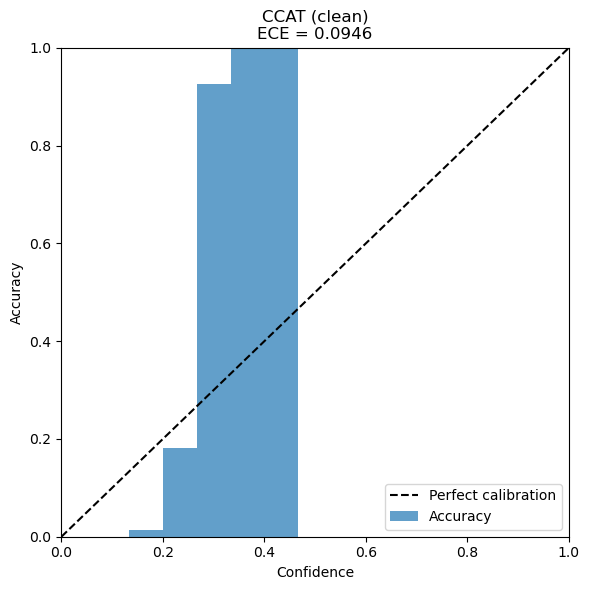

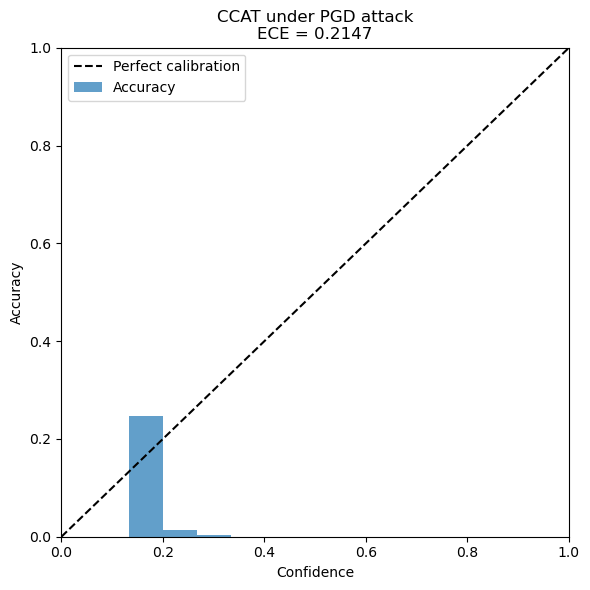

CCAT Clean=0.1594  PGD=0.0341  ECE clean=0.0946  ECE adv=0.2147


In [ ]:
# Adversarial training with CCAT
import importlib, attacks as atk_mod
importlib.reload(atk_mod)
from attacks import ccat_train_one_epoch, evaluate_clean_and_pgd

torch.manual_seed(SEED)
ccat_model     = get_resnet18(num_classes=num_classes).to(device)
ccat_criterion = nn.CrossEntropyLoss()
ccat_optimizer = torch.optim.Adam(ccat_model.parameters(), lr=1e-3, weight_decay=1e-4)
ccat_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ccat_optimizer, T_max=30)

ccat_epochs = 30
for epoch in range(ccat_epochs):
    t_loss, t_acc = ccat_train_one_epoch(
        ccat_model, train_dl, ccat_criterion, ccat_optimizer, device,
        num_classes=num_classes, eps=8/255, alpha=2/255, steps=5, lambda_adv=1.0
    )
    v_loss, v_acc = evaluate(ccat_model, val_dl, ccat_criterion, device)
    ccat_scheduler.step()
    print(f'Epoch [{epoch+1}/{ccat_epochs}] Train {t_acc:.4f} | Val {v_acc:.4f}')

ccat_clean_acc, ccat_pgd_acc = evaluate_clean_and_pgd(ccat_model, test_dl, device, eps=8/255, steps=10)
ccat_confs, ccat_preds, ccat_labels_np = collect_predictions(ccat_model, test_dl, device)
ccat_ece = reliability_diagram(ccat_confs, ccat_preds, ccat_labels_np,
    title='CCAT (clean)',
    save_path=os.path.join(plot_dir, f'{dataset_name}_reliability_ccat.png'))
adv_confs_ccat, adv_preds_ccat, _ = collect_adversarial_predictions(ccat_model, test_dl, device)
adv_ece_ccat = reliability_diagram(adv_confs_ccat, adv_preds_ccat, ccat_labels_np,
    title='CCAT under PGD attack',
    save_path=os.path.join(plot_dir, f'{dataset_name}_reliability_ccat_adv.png'))
print(f'CCAT Clean={ccat_clean_acc:.4f}  PGD={ccat_pgd_acc:.4f}  ECE clean={ccat_ece:.4f}  ECE adv={adv_ece_ccat:.4f}')
torch.save(ccat_model.state_dict(), os.path.join(model_dir, f'resnet18_{dataset_name}_ccat.pth'))


## Full Comparison Matrix

Rows = training method, columns = metric. **ECE (adv)** is the core thesis metric: calibration quality under PGD attack.

Method                   Clean  PGD-10  ECE clean   ECE adv
-----------------------------------------------------------
Madry + CRL             0.9059  0.7717     0.0179    0.0718
Saved to outputs\cifar10\2026-05-04_13-55-45\csv\cifar10_comparison_matrix.csv (1/6 rows)


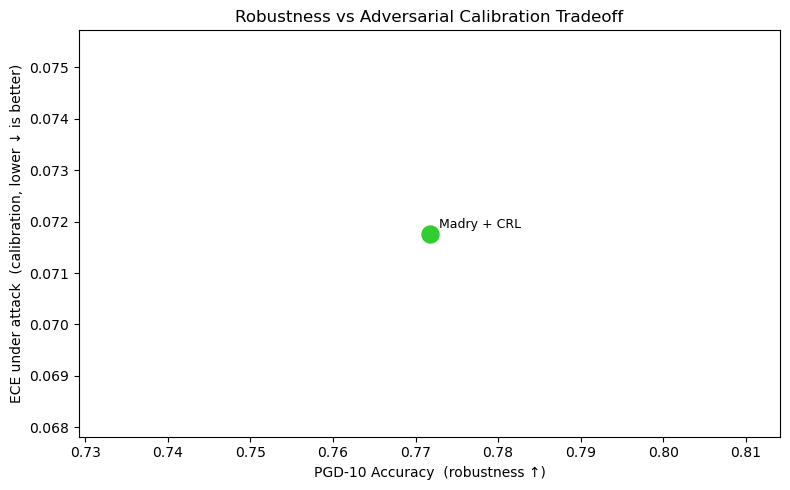

In [13]:
# Only include rows whose variables are defined (safe to run mid-experiment)
_candidates = [
    ('ERM (baseline)',     'clean_acc',          'pgd_acc',           'ece',            'adv_ece_base'),
    ('ERM + Temp. Scaling','clean_acc',           'pgd_acc',           'ts_ece',          'adv_ece_ts'),
    ('ERM + CRL',          'crl_clean_acc',       'crl_pgd_acc',       'crl_ece',         'adv_ece_crl'),
    ('Madry (adv. train)', 'adv_clean_acc',       'adv_pgd_acc',       'adv_ece',         'adv_ece_madry'),
    ('Madry + CRL',        'madry_crl_clean_acc', 'madry_crl_pgd_acc', 'madry_crl_ece',   'adv_ece_madry_crl'),
    ('CCAT',               'ccat_clean_acc',      'ccat_pgd_acc',      'ccat_ece',        'adv_ece_ccat'),
]
_g = globals()
rows = [(lbl, _g[ca], _g[pa], _g[ec], _g[ea])
        for lbl, ca, pa, ec, ea in _candidates
        if all(v in _g for v in (ca, pa, ec, ea))]

hdr = f"{'Method':<22} {'Clean':>7} {'PGD-10':>7} {'ECE clean':>10} {'ECE adv':>9}"
print(hdr)
print('-' * len(hdr))
for label, ca, pa, ec, ea in rows:
    print(f'{label:<22} {ca:>7.4f} {pa:>7.4f} {ec:>10.4f} {ea:>9.4f}')

results_df = pd.DataFrame(rows, columns=['method','clean_acc','pgd10_acc','ece_clean','ece_adv'])
csv_path = os.path.join(csv_dir, f'{dataset_name}_comparison_matrix.csv')
results_df.to_csv(csv_path, index=False)
print(f'Saved to {csv_path} ({len(rows)}/6 rows)')

fig, ax = plt.subplots(figsize=(8, 5))
all_colors = {'ERM (baseline)':'steelblue', 'ERM + Temp. Scaling':'deepskyblue',
              'ERM + CRL':'orange', 'Madry (adv. train)':'green',
              'Madry + CRL':'limegreen', 'CCAT':'red'}
for (label, ca, pa, ec, ea) in rows:
    ax.scatter(pa, ea, s=150, color=all_colors[label], zorder=5)
    ax.annotate(label, (pa, ea), textcoords='offset points', xytext=(7, 4), fontsize=9)
ax.set_xlabel('PGD-10 Accuracy  (robustness ↑)')
ax.set_ylabel('ECE under attack  (calibration, lower ↓ is better)')
ax.set_title('Robustness vs Adversarial Calibration Tradeoff')
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f'{dataset_name}_robustness_vs_adv_ece.png'), dpi=300)
plt.show()


## Standalone Evaluation
Loads saved model checkpoints and CSVs from the latest run directory,
recomputes all metrics from scratch (no training needed), and produces
comparison plots. Safe to run after a kernel restart.

In [ ]:
# Standalone evaluation
# Loads checkpoints, recomputes metrics, saves CSV
# Requires models, calibration, attacks, data modules in the working directory

import glob, os
import numpy as np
import pandas as pd
import torch

from models import get_resnet18
from calibration import (collect_predictions, compute_ece,
                          TemperatureScaler, collect_adversarial_predictions)
from attacks import evaluate_clean_and_pgd
from data import get_cifar_loaders

EVAL_DATASET = "cifar10"
EVAL_DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

_run_dirs = sorted(glob.glob(os.path.join("outputs", EVAL_DATASET, "*")))
if not _run_dirs:
    raise FileNotFoundError(f"No runs found under outputs/{EVAL_DATASET}/")
_run_dir   = _run_dirs[-1]
_model_dir = os.path.join(_run_dir, "models")
_csv_dir   = os.path.join(_run_dir, "csv")
_plot_dir  = os.path.join(_run_dir, "plots")
print(f"Run: {_run_dir}")

(_, _val_ds, _test_ds,
 _, _val_dl, _test_dl,
 _classes, _stats, _n_classes) = get_cifar_loaders(
    dataset_name=EVAL_DATASET, batch_size=128, seed=42)


def _load(fname):
    path = os.path.join(_model_dir, fname)
    if not os.path.exists(path):
        return None
    m = get_resnet18(num_classes=_n_classes).to(EVAL_DEVICE)
    m.load_state_dict(torch.load(path, map_location=EVAL_DEVICE, weights_only=True))
    m.eval()
    return m


def _eval(label, model):
    clean_acc, pgd_acc = evaluate_clean_and_pgd(
        model, _test_dl, EVAL_DEVICE, eps=8/255, alpha=2/255, steps=10)
    confs, preds, labs = collect_predictions(model, _test_dl, EVAL_DEVICE)
    ece_c = compute_ece(confs, preds, labs)
    adv_confs, adv_preds, _ = collect_adversarial_predictions(model, _test_dl, EVAL_DEVICE)
    ece_a = compute_ece(adv_confs, adv_preds, labs)
    print(f"  {label:<26}  clean={clean_acc:.4f}  pgd={pgd_acc:.4f}  "
          f"ece_c={ece_c:.4f}  ece_a={ece_a:.4f}")
    return {
        "method": label, "clean_acc": clean_acc, "pgd10_acc": pgd_acc,
        "ece_clean": ece_c, "ece_adv": ece_a,
        "confs": confs, "preds": preds, "labs": labs,
        "adv_confs": adv_confs, "adv_preds": adv_preds,
    }


_checkpoints = [
    ("ERM (baseline)",     f"resnet18_{EVAL_DATASET}.pth"),
    ("ERM + CRL",          f"resnet18_{EVAL_DATASET}_crl.pth"),
    ("Madry (adv. train)", f"resnet18_{EVAL_DATASET}_adv.pth"),
    ("Madry + CRL",        f"resnet18_{EVAL_DATASET}_madry_crl.pth"),
    ("CCAT",               f"resnet18_{EVAL_DATASET}_ccat.pth"),
]

print("Evaluating checkpoints...")
eval_rows = []
_loaded_models = {}
for _lbl, _fname in _checkpoints:
    _m = _load(_fname)
    if _m is None:
        print(f"  [skip] {_lbl} — {_fname} not found")
        continue
    _loaded_models[_lbl] = _m
    eval_rows.append(_eval(_lbl, _m))

# Temperature scaling is fitted on val set, no separate checkpoint needed
_base = _loaded_models.get("ERM (baseline)")
if _base is not None:
    print("  Fitting temperature scaler on val set...")
    _ts = TemperatureScaler(_base).to(EVAL_DEVICE)
    _ts.fit(_val_dl, EVAL_DEVICE)
    _ts_c, _ts_p, _ts_l = collect_predictions(_ts, _test_dl, EVAL_DEVICE)
    _ts_ece_c = compute_ece(_ts_c, _ts_p, _ts_l)
    _ts_ac, _ts_ap, _ = collect_adversarial_predictions(_ts, _test_dl, EVAL_DEVICE)
    _ts_ece_a = compute_ece(_ts_ac, _ts_ap, _ts_l)
    _ts_row = {
        "method": "ERM + Temp. Scaling",
        "clean_acc": eval_rows[0]["clean_acc"],
        "pgd10_acc": eval_rows[0]["pgd10_acc"],
        "ece_clean": _ts_ece_c, "ece_adv": _ts_ece_a,
        "confs": _ts_c, "preds": _ts_p, "labs": _ts_l,
        "adv_confs": _ts_ac, "adv_preds": _ts_ap,
    }
    eval_rows.insert(1, _ts_row)
    print(f"  {'ERM + Temp. Scaling':<26}  T={_ts.temperature.item():.4f}  "
          f"ece_c={_ts_ece_c:.4f}  ece_a={_ts_ece_a:.4f}")

_keys = ["method", "clean_acc", "pgd10_acc", "ece_clean", "ece_adv"]
eval_df = pd.DataFrame([{k: r[k] for k in _keys} for r in eval_rows])
_csv_out = os.path.join(_csv_dir, f"{EVAL_DATASET}_eval_recomputed.csv")
eval_df.to_csv(_csv_out, index=False)
print(f"\nSaved -> {_csv_out}")
print(eval_df.to_string(index=False))


Run: outputs\cifar10\2026-05-04_13-55-45


c:\Users\leven\anaconda3\envs\thesis\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Evaluating checkpoints...
  ERM (baseline)              clean=0.9279  pgd=0.0377  ece_c=0.0441  ece_a=0.9519
  ERM + CRL                   clean=0.9229  pgd=0.0653  ece_c=0.0185  ece_a=0.8929
  Madry (adv. train)          clean=0.9065  pgd=0.7601  ece_c=0.0279  ece_a=0.1398
  Madry + CRL                 clean=0.9059  pgd=0.7717  ece_c=0.0179  ece_a=0.0716
  CCAT                        clean=0.1594  pgd=0.0342  ece_c=0.0946  ece_a=0.2147
  Fitting temperature scaler on val set...
Optimal temperature: 1.2028
  ERM + Temp. Scaling         T=1.2028  ece_c=0.0373  ece_a=0.9517

Saved -> outputs\cifar10\2026-05-04_13-55-45\csv\cifar10_eval_recomputed.csv
             method  clean_acc  pgd10_acc  ece_clean  ece_adv
     ERM (baseline)     0.9279     0.0377   0.044080 0.951933
ERM + Temp. Scaling     0.9279     0.0377   0.037301 0.951694
          ERM + CRL     0.9229     0.0653   0.018493 0.892874
 Madry (adv. train)     0.9065     0.7601   0.027891 0.139791
        Madry + CRL     0.9059   

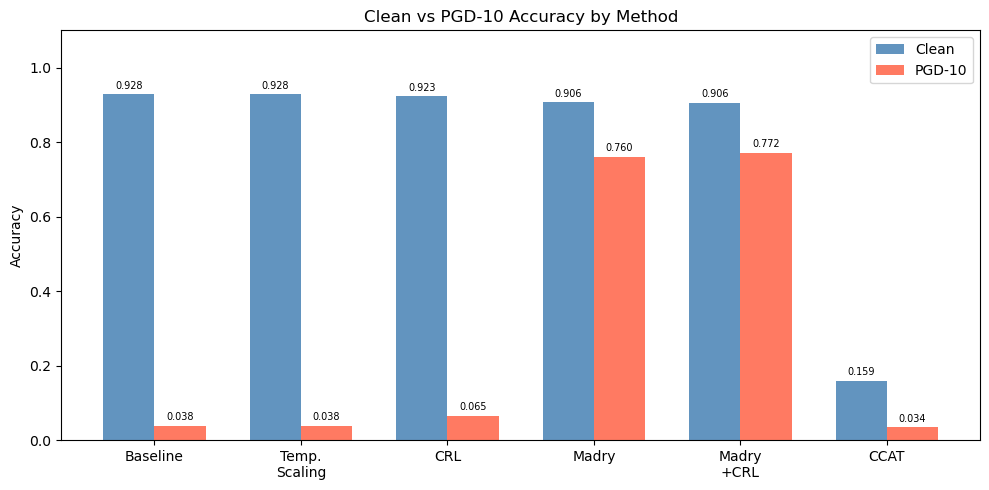

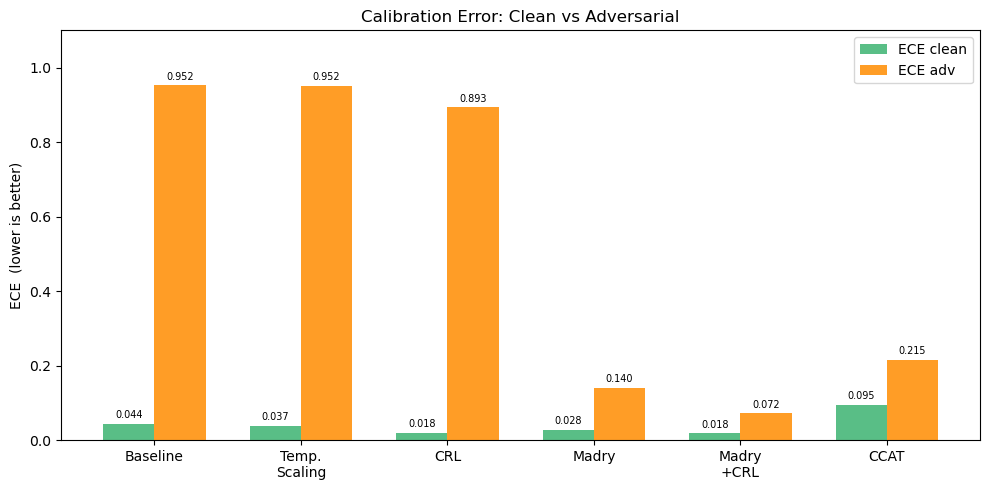

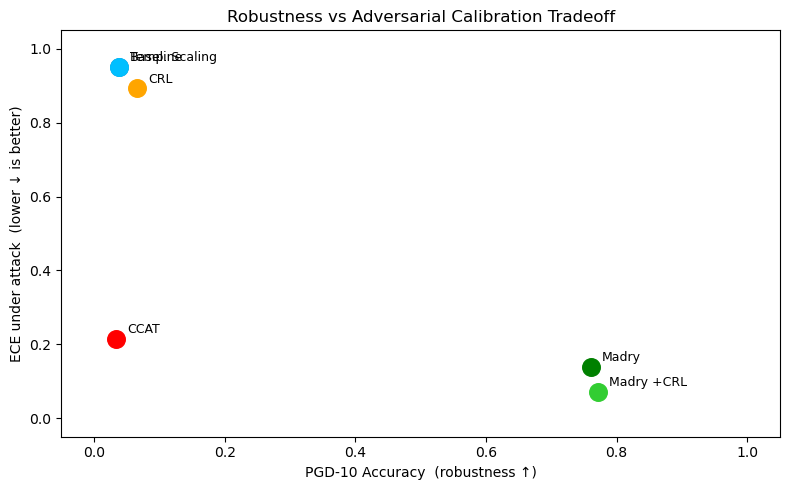

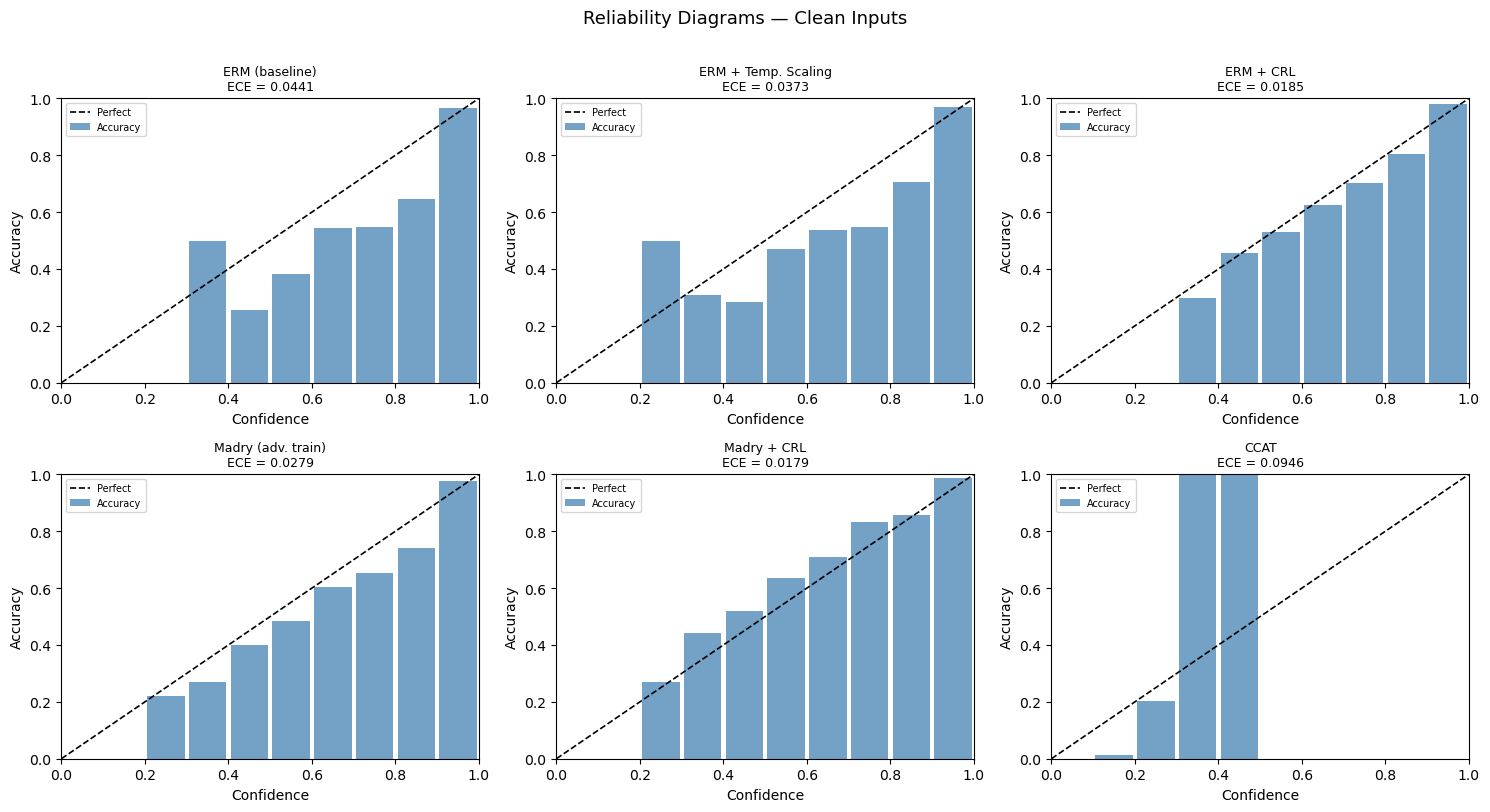

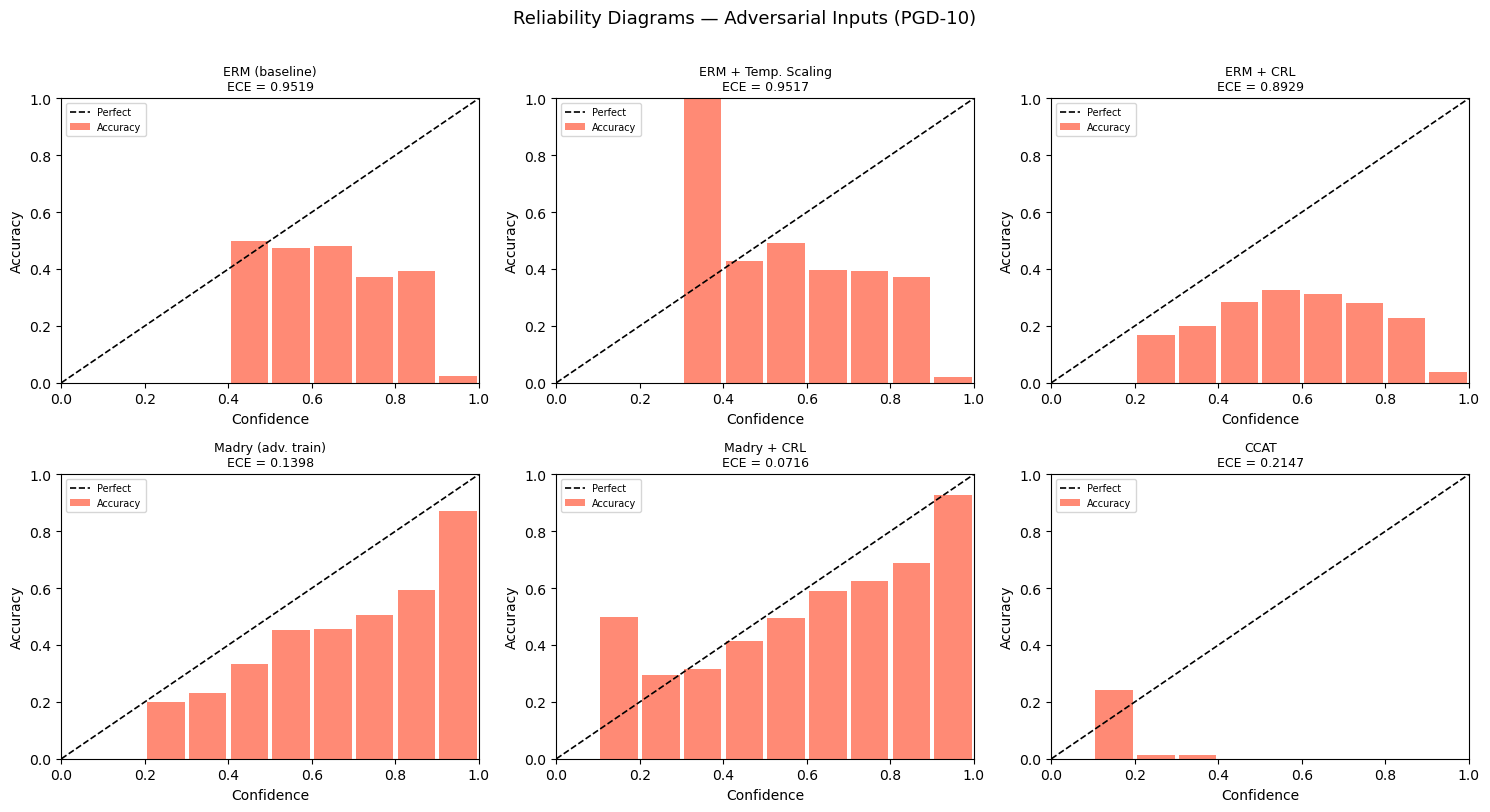

In [ ]:
# Comparison plots
# Requires eval_rows, _plot_dir, EVAL_DATASET from prev cell

import os
import matplotlib.pyplot as plt
import numpy as np

_methods = [r["method"] for r in eval_rows]
_short = [m.replace("ERM (baseline)", "Baseline")
           .replace("ERM + Temp. Scaling", "Temp.\nScaling")
           .replace("ERM + CRL", "CRL")
           .replace("Madry (adv. train)", "Madry")
           .replace("Madry + CRL", "Madry\n+CRL") for m in _methods]
_x = np.arange(len(eval_rows))
_w = 0.35

# ── 1: Clean vs PGD-10 Accuracy ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(_x - _w/2, [r["clean_acc"]  for r in eval_rows], _w,
       label="Clean", color="steelblue", alpha=0.85)
ax.bar(_x + _w/2, [r["pgd10_acc"]  for r in eval_rows], _w,
       label="PGD-10", color="tomato", alpha=0.85)
for i, r in enumerate(eval_rows):
    ax.text(i - _w/2, r["clean_acc"] + 0.01, f"{r['clean_acc']:.3f}",
            ha="center", va="bottom", fontsize=7)
    ax.text(i + _w/2, r["pgd10_acc"] + 0.01, f"{r['pgd10_acc']:.3f}",
            ha="center", va="bottom", fontsize=7)
ax.set_xticks(_x); ax.set_xticklabels(_short, rotation=0, ha="center")
ax.set_ylabel("Accuracy"); ax.set_ylim(0, 1.1)
ax.set_title("Clean vs PGD-10 Accuracy by Method")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(_plot_dir, f"{EVAL_DATASET}_compare_accuracy.png"), dpi=150)
plt.show()

# ECE Clean vs ECE Adversarial
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(_x - _w/2, [r["ece_clean"] for r in eval_rows], _w,
       label="ECE clean", color="mediumseagreen", alpha=0.85)
ax.bar(_x + _w/2, [r["ece_adv"]   for r in eval_rows], _w,
       label="ECE adv",   color="darkorange", alpha=0.85)
for i, r in enumerate(eval_rows):
    ax.text(i - _w/2, r["ece_clean"] + 0.01, f"{r['ece_clean']:.3f}",
            ha="center", va="bottom", fontsize=7)
    ax.text(i + _w/2, r["ece_adv"]   + 0.01, f"{r['ece_adv']:.3f}",
            ha="center", va="bottom", fontsize=7)
ax.set_xticks(_x); ax.set_xticklabels(_short, rotation=0, ha="center")
ax.set_ylabel("ECE  (lower is better)"); ax.set_ylim(0, 1.1)
ax.set_title("Calibration Error: Clean vs Adversarial")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(_plot_dir, f"{EVAL_DATASET}_compare_ece.png"), dpi=150)
plt.show()

# Robustness vs Adversarial ECE Scatter
_palette = {
    "ERM (baseline)": "steelblue",  "ERM + Temp. Scaling": "deepskyblue",
    "ERM + CRL": "orange",          "Madry (adv. train)": "green",
    "Madry + CRL": "limegreen",     "CCAT": "red",
}
fig, ax = plt.subplots(figsize=(8, 5))
for r, s in zip(eval_rows, _short):
    ax.scatter(r["pgd10_acc"], r["ece_adv"],
               s=160, color=_palette.get(r["method"], "gray"), zorder=5)
    ax.annotate(s.replace("\n", " "), (r["pgd10_acc"], r["ece_adv"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xlabel("PGD-10 Accuracy  (robustness \u2191)")
ax.set_ylabel("ECE under attack  (lower \u2193 is better)")
ax.set_title("Robustness vs Adversarial Calibration Tradeoff")
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(_plot_dir, f"{EVAL_DATASET}_scatter_robustness_ece.png"), dpi=150)
plt.show()

# Reliability Diagram Grids
def _reliability_grid(rows, use_adv=False, suptitle="", fname=""):
    n = len(rows)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()
    bins = np.linspace(0, 1, 11)
    centers = (bins[:-1] + bins[1:]) / 2
    bin_w = bins[1] - bins[0]
    bar_color = "tomato" if use_adv else "steelblue"

    for i, r in enumerate(rows):
        ax = axes[i]
        confs_i = r["adv_confs"] if use_adv else r["confs"]
        preds_i = r["adv_preds"] if use_adv else r["preds"]
        labs_i  = r["labs"]
        bin_idx = np.clip(np.digitize(confs_i, bins) - 1, 0, len(bins) - 2)
        acc_b = []
        for j in range(len(centers)):
            mask = bin_idx == j
            acc_b.append((preds_i[mask] == labs_i[mask]).mean() if mask.any() else 0.0)
        ax.bar(centers, acc_b, width=bin_w * 0.9, alpha=0.75,
               color=bar_color, label="Accuracy")
        ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Perfect")
        ece_val = r["ece_adv"] if use_adv else r["ece_clean"]
        ax.set_title(f"{r['method']}\nECE = {ece_val:.4f}", fontsize=9)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
        ax.legend(fontsize=7)

    for j in range(len(rows), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout()
    if fname:
        plt.savefig(os.path.join(_plot_dir, fname), dpi=150, bbox_inches="tight")
    plt.show()

_reliability_grid(
    eval_rows, use_adv=False,
    suptitle="Reliability Diagrams — Clean Inputs",
    fname=f"{EVAL_DATASET}_reliability_clean_grid.png",
)
_reliability_grid(
    eval_rows, use_adv=True,
    suptitle="Reliability Diagrams — Adversarial Inputs (PGD-10)",
    fname=f"{EVAL_DATASET}_reliability_adv_grid.png",
)


## Risk Detection Layer Experiment (Mahalanobis)

Post-hoc risk layer applied to saved checkpoints so no backbone retraining needed.

The idea is that the penultimate layer features of clean training samples define class-conditional Gaussians. At test time, the Mahalanobis distance from an input's features to the nearest
class centre is used to dynamically raise the output temperature

With high distance, T is also going to be high, which softens the per-input predictions.
Alpha is tuned on the validation set to minimise ECE_clean.

Three models are wrapped: Baseline, Madry, Madry+CRL.

Reference: Lee et al. (2018), *A Simple Unified Framework for Detecting Out-of-Distribution
Samples and Adversarial Attacks*, NeurIPS.

In [ ]:
# Risk Layer Setup
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from models import get_resnet18
from calibration import (collect_predictions, compute_ece, reliability_diagram,
                          collect_adversarial_predictions)
from attacks import evaluate_clean_and_pgd
from data import get_cifar_loaders

RISK_DATASET = "cifar10"
RISK_DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# Reuse the latest run directory
_run_dirs  = sorted(glob.glob(os.path.join("outputs", RISK_DATASET, "*")))
_run_dir   = _run_dirs[-1]
_model_dir = os.path.join(_run_dir, "models")
_plot_dir  = os.path.join(_run_dir, "plots")
print(f"Run dir: {_run_dir}")

# Data 
# train_dl for fitting class statistics, val_dl for alpha tuning
(train_dataset, val_dataset, test_dataset,
 train_dl, val_dl, test_dl,
 _classes, _stats, _n_classes) = get_cifar_loaders(
    dataset_name=RISK_DATASET, batch_size=128, seed=42)

def _load(fname):
    path = os.path.join(_model_dir, fname)
    if not os.path.exists(path):
        print(f"  [skip] {fname} not found")
        return None
    m = get_resnet18(num_classes=_n_classes).to(RISK_DEVICE)
    m.load_state_dict(torch.load(path, map_location=RISK_DEVICE, weights_only=True))
    m.eval()
    return m


class MahalanobisRiskWrapper(nn.Module):
    """
    Wraps a trained model with a post-hoc Mahalanobis-distance risk detector
    
    Penultimate layer features (after avgpool, before fc) of the training set
    are used to fit class-conditional Gaussians with a shared covariance matrix

    At inference, the minimum Mahalanobis distance from the input's features
    to any class centre is used as a dynamic temperature:
    
       T(x) = 1 + alpha * r(x)
       r(x) = min_k  (h - mu_k)^T  Sigma^{-1}  (h - mu_k)
    
    With high distance, T is also going to be high, which softens the per-input predictions
    Alpha is tuned on the validation set to minimise ECE_clean
    
    Reference: Lee et al. (2018), NeurIPS: 'A Simple Unified Framework for Detecting Out-of-Distribution Samples and Adversarial Attacks'"""

    def __init__(self, model, alpha=0.001):
        super().__init__()
        self.model       = model
        self.alpha       = alpha
        self.class_means = None # (K, d) class centres in feature space
        self.precision   = None # (d, d) inverse of shared covariance
        self._features   = None # populated by forward hook on each pass

        # Hook on avgpool, which captures (B,512,1,1) and is flattened to (B,512)
        # This is the penultimate representation before the linear classifier
        self.model.avgpool.register_forward_hook(self._hook)

    def _hook(self, module, inp, out):
        self._features = out.flatten(1)   # (B, d)

    @torch.no_grad()
    def fit(self, dataloader, device, num_classes):
        # Pass the training set through the frozen backbone once to collect penultimate features, then compute:
        #   - class means mu_k  (one per class)
        #   - pooled within-class covariance Sigma
        #   - precision matrix  Sigma^{-1}  (with small diagonal regularisation)
        print("  Collecting training features...")
        self.model.eval()
        all_feats, all_labels = [], []

        for images, labels in dataloader:
            self.model(images.to(device)) # triggers hook
            all_feats.append(self._features.cpu())
            all_labels.append(labels.cpu())

        feats  = torch.cat(all_feats) # (N, d)
        labels = torch.cat(all_labels) # (N,)
        d      = feats.shape[1]

        # Class means
        means = torch.zeros(num_classes, d)
        for k in range(num_classes):
            mask = labels == k
            if mask.any():
                means[k] = feats[mask].mean(0)

        # Pooled within-class covariance
        cov     = torch.zeros(d, d)
        n_total = 0
        for k in range(num_classes):
            mask = labels == k
            if mask.any():
                diff    = feats[mask] - means[k] # (n_k, d)
                cov    += diff.T @ diff
                n_total += mask.sum().item()
        cov /= n_total
        cov += 1e-5 * torch.eye(d) # regularise for invertibility

        self.class_means = means.to(device)
        self.precision   = torch.linalg.inv(cov).to(device)
        print(f"  Fitted: N={n_total}, d={d}, K={num_classes}")
        return self

    def _mahal(self, feats):
        """Minimum Mahalanobis distance to any class centre
        Get: (B, d), return: (B,), the risk score per sample
        
        For each class k the quadratic form is:
          score_k = (h - mu_k)^T  Sigma^{-1}  (h - mu_k) = sum_j [ (h - mu_k) @ Sigma^{-1} ]_j * (h - mu_k)_j
        We take the minimum over classes (nearest class centre)"""
        scores = []
        for k in range(self.class_means.shape[0]):
            diff    = feats - self.class_means[k] # (B, d)
            score_k = (diff @ self.precision * diff).sum(-1) # (B,) quadratic form
            scores.append(score_k)
        return torch.stack(scores, dim=1).min(1).values # (B,)

    def forward(self, x):
        logits = self.model(x) # (B, K), triggers hook
        feats  = self._features # (B, d), from hook
        risk   = self._mahal(feats) # (B,)
        T      = (1.0 + self.alpha * risk).unsqueeze(1) # (B, 1)
        return logits / T # softer where risk is high

    @torch.no_grad()
    def tune_alpha(self, val_dl, device, label="model",
                   alphas=(0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05)):
        # Grid search: pick alpha that minimises ECE_clean on the validation set
        # Tuning on clean data is conservative, same alpha applied to adv inputs
        print(f"  Tuning alpha for {label}...")
        best_alpha, best_ece = None, float("inf")
        for a in alphas:
            self.alpha = a
            c, p, l   = collect_predictions(self, val_dl, device)
            ece        = compute_ece(c, p, l)
            flag       = " <-- best" if ece < best_ece else ""
            print(f"    alpha={a:.4f}  ECE_val={ece:.4f}{flag}")
            if ece < best_ece:
                best_ece, best_alpha = ece, a
        self.alpha = best_alpha
        print(f"  => alpha={best_alpha}  (ECE_val={best_ece:.4f})")
        return best_alpha


print("MahalanobisRiskWrapper defined.")
print(f"Device: {RISK_DEVICE}")


In [ ]:
# Fit, Tune, and Evaluate 
# Loads three saved checkpoints and wraps each with the Mahalanobis risk layer
# Tuning is fast (val set only) 
# Evaluation runs PGD-10 on the full test set

_checkpoints = [
    ("Baseline + Mahalanobis",  f"resnet18_{RISK_DATASET}.pth"),
    ("Madry + Mahalanobis",     f"resnet18_{RISK_DATASET}_adv.pth"),
    ("Madry+CRL + Mahalanobis", f"resnet18_{RISK_DATASET}_madry_crl.pth"),
]

risk_rows = []

for label, fname in _checkpoints:
    print("=" * 60)
    print(f" {label}")
    print("=" * 60)

    base = _load(fname)
    if base is None:
        continue

    wrapper  = MahalanobisRiskWrapper(base, alpha=0.001).to(RISK_DEVICE)
    wrapper.fit(train_dl, RISK_DEVICE, _n_classes)
    best_a   = wrapper.tune_alpha(val_dl, RISK_DEVICE, label=label)

    print("  Evaluating clean + PGD-10...")
    clean_acc, pgd_acc = evaluate_clean_and_pgd(
        wrapper, test_dl, RISK_DEVICE, eps=8/255, alpha=2/255, steps=10)

    print("  Collecting clean calibration...")
    confs, preds, labs = collect_predictions(wrapper, test_dl, RISK_DEVICE)
    ece_c              = compute_ece(confs, preds, labs)

    print("  Collecting adversarial calibration (PGD-10)...")
    adv_c, adv_p, _    = collect_adversarial_predictions(wrapper, test_dl, RISK_DEVICE)
    ece_a              = compute_ece(adv_c, adv_p, labs)

    print(f"\n  {label}")
    print(f"  Clean={clean_acc:.4f}  PGD={pgd_acc:.4f}  "
          f"ECE_clean={ece_c:.4f}  ECE_adv={ece_a:.4f}")

    risk_rows.append({
        "method":    label,
        "clean_acc": clean_acc,
        "pgd10_acc": pgd_acc,
        "ece_clean": ece_c,
        "ece_adv":   ece_a,
        "confs":     confs,
        "preds":     preds,
        "labs":      labs,
        "adv_confs": adv_c,
        "adv_preds": adv_p,
        "alpha":     best_a,
    })

    # Reliability diagrams, clean and adversarial
    slug = label.lower().replace(" ", "_").replace("+", "plus")
    reliability_diagram(
        confs, preds, labs,
        title=f"{label} — clean  (alpha={best_a})",
        save_path=os.path.join(_plot_dir, f"{RISK_DATASET}_risk_{slug}_clean.png"))
    reliability_diagram(
        adv_c, adv_p, labs,
        title=f"{label} — adversarial  (alpha={best_a})",
        save_path=os.path.join(_plot_dir, f"{RISK_DATASET}_risk_{slug}_adv.png"))

print("\nAll risk-layer evaluations complete.")


Method                           Clean  PGD-10   ECE_c   ECE_a
--------------------------------------------------------------
Original methods:
  ERM (baseline)                0.9279  0.0381  0.0441  0.9515
  ERM + Temp. Scaling           0.9279  0.0381  0.0373  0.9518
  ERM + CRL                     0.9229  0.0670  0.0185  0.8925
  Madry                         0.9065  0.7598  0.0279  0.1397
  Madry + CRL                   0.9059  0.7717  0.0179  0.0718

With Mahalanobis risk layer:
  Baseline + Mahalanobis        0.9279  0.0519  0.0075  0.8946
  Madry + Mahalanobis           0.9065  0.7615  0.0098  0.1093
  Madry+CRL + Mahalanobis       0.9059  0.7719  0.0199  0.0632

CSV saved to outputs\cifar10\2026-05-04_13-55-45\csv


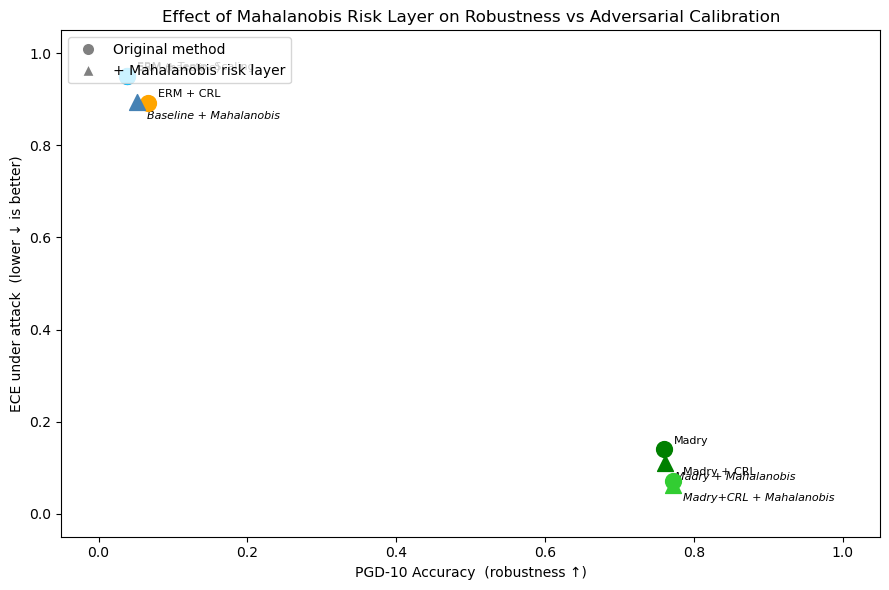

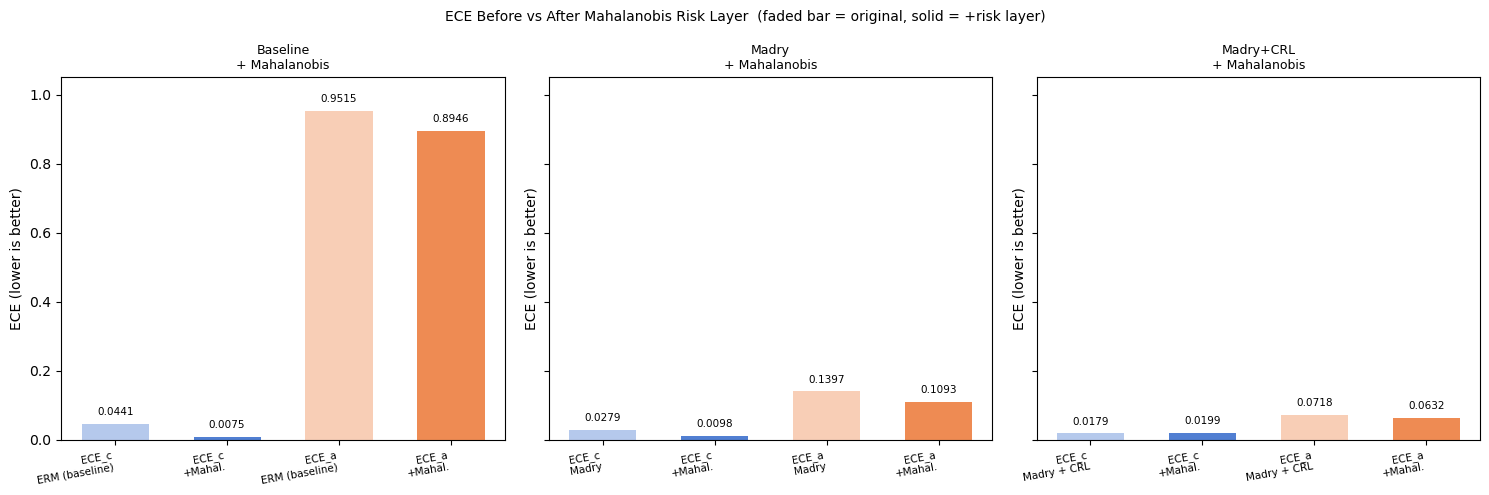

In [ ]:
# Comparison: original methods vs Mahalanobis-enhanced
from matplotlib.lines import Line2D

_orig = [
    ("ERM (baseline)",      0.9279, 0.0381, 0.0441, 0.9515),
    ("ERM + Temp. Scaling", 0.9279, 0.0381, 0.0373, 0.9518),
    ("ERM + CRL",           0.9229, 0.0670, 0.0185, 0.8925),
    ("Madry",               0.9065, 0.7598, 0.0279, 0.1397),
    ("Madry + CRL",         0.9059, 0.7717, 0.0179, 0.0718),
]

# Print comparison table
hdr = f"{'Method':<30} {'Clean':>7} {'PGD-10':>7} {'ECE_c':>7} {'ECE_a':>7}"
sep = "-" * len(hdr)
print(hdr); print(sep)
print("Original methods:")
for name, ca, pa, ec, ea in _orig:
    print(f"  {name:<28} {ca:>7.4f} {pa:>7.4f} {ec:>7.4f} {ea:>7.4f}")
print("\nWith Mahalanobis risk layer:")
for r in risk_rows:
    print(f"  {r['method']:<28} {r['clean_acc']:>7.4f} {r['pgd10_acc']:>7.4f} "
          f"{r['ece_clean']:>7.4f} {r['ece_adv']:>7.4f}")

# Save combined CSV
_metric_keys = ["method", "clean_acc", "pgd10_acc", "ece_clean", "ece_adv"]
_all = [{"method": n, "clean_acc": ca, "pgd10_acc": pa, "ece_clean": ec, "ece_adv": ea}
        for n, ca, pa, ec, ea in _orig]
_all += [{k: r[k] for k in _metric_keys} for r in risk_rows]
_csv_dir = os.path.join(_run_dir, "csv")
pd.DataFrame(_all).to_csv(
    os.path.join(_csv_dir, f"{RISK_DATASET}_risk_layer_comparison.csv"), index=False)
print(f"\nCSV saved to {_csv_dir}")

# Plot 1: Robustness vs adversarial ECE scatter
_palette_orig = {
    "ERM (baseline)":      ("steelblue",  "o"),
    "ERM + Temp. Scaling": ("deepskyblue","o"),
    "ERM + CRL":           ("orange",     "o"),
    "Madry":               ("green",      "o"),
    "Madry + CRL":         ("limegreen",  "o"),
}
_palette_risk = {
    "Baseline + Mahalanobis":  ("steelblue", "^"),
    "Madry + Mahalanobis":     ("green",     "^"),
    "Madry+CRL + Mahalanobis": ("limegreen", "^"),
}

fig, ax = plt.subplots(figsize=(9, 6))
for name, ca, pa, ec, ea in _orig:
    col, mrk = _palette_orig.get(name, ("gray", "o"))
    ax.scatter(pa, ea, s=130, color=col, marker=mrk, zorder=5)
    ax.annotate(name, (pa, ea), textcoords="offset points",
                xytext=(7, 4), fontsize=8)
for r in risk_rows:
    col, mrk = _palette_risk.get(r["method"], ("purple", "^"))
    ax.scatter(r["pgd10_acc"], r["ece_adv"], s=130, color=col,
               marker=mrk, zorder=5)
    ax.annotate(r["method"], (r["pgd10_acc"], r["ece_adv"]),
                textcoords="offset points", xytext=(7, -12),
                fontsize=8, style="italic")

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markersize=9, label="Original method"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="gray",
           markersize=9, label="+ Mahalanobis risk layer"),
]
ax.legend(handles=legend_elements, loc="upper left")
ax.set_xlabel("PGD-10 Accuracy  (robustness ↑)")
ax.set_ylabel("ECE under attack  (lower ↓ is better)")
ax.set_title("Effect of Mahalanobis Risk Layer on Robustness vs Adversarial Calibration")
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(_plot_dir,
    f"{RISK_DATASET}_risk_layer_scatter.png"), dpi=150)
plt.show()

# Plot 2: ECE bars, original vs risk-enhanced side by side
_orig_map = {
    "Baseline + Mahalanobis":  ("ERM (baseline)", 0.0441, 0.9515),
    "Madry + Mahalanobis":     ("Madry",          0.0279, 0.1397),
    "Madry+CRL + Mahalanobis": ("Madry + CRL",    0.0179, 0.0718),
}

fig, axes = plt.subplots(1, len(risk_rows),
                         figsize=(5 * len(risk_rows), 5), sharey=True)
if len(risk_rows) == 1:
    axes = [axes]

for ax, r in zip(axes, risk_rows):
    orig_name, orig_ec, orig_ea = _orig_map.get(r["method"], ("", 0, 0))
    x    = [0, 1, 2, 3]
    vals = [orig_ec, r["ece_clean"], orig_ea, r["ece_adv"]]
    cols = ["#4878D0", "#4878D0", "#EE854A", "#EE854A"]
    alph = [0.40, 0.95, 0.40, 0.95]
    bars = ax.bar(x, vals, color=cols, width=0.6)
    for bar, a in zip(bars, alph):
        bar.set_alpha(a)
    tick_labels = [
        f"ECE_c\n{orig_name}",
        f"ECE_c\n+Mahal.",
        f"ECE_a\n{orig_name}",
        f"ECE_a\n+Mahal.",
    ]
    ax.set_xticks(x); ax.set_xticklabels(tick_labels, fontsize=7.5, rotation=10, ha="right")
    ax.set_title(r["method"].replace(" + Mahalanobis", "\n+ Mahalanobis"), fontsize=9)
    ax.set_ylabel("ECE (lower is better)")
    ax.set_ylim(0, 1.05)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                f"{val:.4f}", ha="center", va="bottom", fontsize=7.5)

fig.suptitle(
    "ECE Before vs After Mahalanobis Risk Layer  (faded bar = original, solid = +risk layer)",
    fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(_plot_dir,
    f"{RISK_DATASET}_risk_layer_ece_bars.png"), dpi=150)
plt.show()
